In [6]:
import sys
import os
# Get the absolute path of the RL_task directory
sys.path.append(os.path.abspath(".."))

In [7]:
import utils
import numpy as np
import pandas as pd
import os
from scipy.stats import chisquare
import matplotlib.pyplot as plt
import seaborn as sns # Loads in the theme
import analysis_functions

#pd.set_option('future.no_silent_downcasting', True)
#pd.set_option('display.max_rows', None)

In [8]:
# Make output folder
output_dir = os.path.join('plots','behavioural_pilot', 'objective_performance')
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

In [9]:
# Preparation
experiment_output_path = r'\\fileserver.dccn.nl\project\3025011.01\data' # 'C:\Users\marti\git\RL_task\experiment_output\behavioural_files'
#experiment_output_path = os.path.join('..', '..', '..', 'phd_1_task', 'experiment_output_verena')

In [10]:
unique_subject_ids = range(0,100) # [1, 2, 4, 33, 99] 
plot_range = [0, 6]

recent_results = analysis_functions.list_files_with_subject_id(experiment_output_path, unique_subject_ids)

In [11]:
print(recent_results)

['\\\\fileserver.dccn.nl\\project\\3025011.01\\data\\sub-02\\ses-03\\rl\\sub-02_d3_rlt_behavioural_output.csv', '\\\\fileserver.dccn.nl\\project\\3025011.01\\data\\sub-03\\ses-03\\rl\\sub-03_d3_rlt_behavioural_output.csv', '\\\\fileserver.dccn.nl\\project\\3025011.01\\data\\sub-05\\ses-03\\rl\\sub-05_d3_rlt_behavioural_output.csv', '\\\\fileserver.dccn.nl\\project\\3025011.01\\data\\sub-06\\ses-03\\rl\\sub-06_d3_rlt_behavioural_output.csv', '\\\\fileserver.dccn.nl\\project\\3025011.01\\data\\sub-07\\ses-03\\rl\\sub-07_d3_rlt_behavioural_output.csv', '\\\\fileserver.dccn.nl\\project\\3025011.01\\data\\sub-08\\ses-03\\rl\\sub-08_d3_rlt_behavioural_output.csv', '\\\\fileserver.dccn.nl\\project\\3025011.01\\data\\sub-09\\ses-03\\rl\\sub-09_d3_rlt_behavioural_output.csv', '\\\\fileserver.dccn.nl\\project\\3025011.01\\data\\sub-11\\ses-03\\rl\\sub-11_d3_rlt_behavioural_output.csv', '\\\\fileserver.dccn.nl\\project\\3025011.01\\data\\sub-12\\ses-03\\rl\\sub-12_d3_rlt_behavioural_output.csv', 

In [12]:
combined_results_dataframe = analysis_functions.combine_result_files(recent_results)
if 'verena' in experiment_output_path:
    combined_results_dataframe = combined_results_dataframe[~combined_results_dataframe['stimuli_type'].isin([2, 4])]

#pd.set_option('display.max_rows', None)     # Show all rows
#pd.set_option('display.max_columns', None)  # Show all columns
print(combined_results_dataframe)

      trial  emotional_cue_time response objectively_correct  \
0         0        1.734607e+09      NaN                Late   
1         1        1.734607e+09     down                Even   
2         2        1.734607e+09       up                Even   
3         3        1.734607e+09       up                Even   
4         4        1.734607e+09     down                Even   
...     ...                 ...      ...                 ...   
8131    447        1.750943e+09       up               False   
8132    448        1.750943e+09     down               False   
8133    449        1.750943e+09       up                True   
8134    450        1.750943e+09     down                True   
8135    451        1.750943e+09       up               False   

     subjectively_correct  response_time   RT_s  feedback_time  stimuli_type  \
0                    Late   1.734607e+09  1.203   1.734607e+09             3   
1                    True   1.734607e+09  0.475   1.734607e+09         

# Analysis
First, we'll look at the reaction time. A plot with all the RT's and average will do.
Second we will look at the percentage of correct answers.
Lastly, we will be looking at a win-stay lose shift to see when behaviour stabilises after a shift in reward contingency.

In [13]:
# Count the amount of subplots necessary based on subject_id only

## Find unique subject IDs
unique_subject_ids = combined_results_dataframe['subject_id'].unique()

## Calculate the number of subplots needed
n_rows = len(unique_subject_ids)  # Each subject gets its own row
n_cols = 1                        # A single column layout since sessions are no longer considered
n_subplots = len(unique_subject_ids)  # Total subplots equal the number of unique subjects

### Make additional column for congruency

In [14]:
combined_results_dataframe['congruency'] = combined_results_dataframe.apply(analysis_functions.check_congruency, axis=1)
print(combined_results_dataframe[['stimuli_type','probability_condition','congruency']])

      stimuli_type  probability_condition   congruency
0                3                     50    undefined
1                1                     50    undefined
2                1                     50    undefined
3                3                     50    undefined
4                1                     50    undefined
...            ...                    ...          ...
8131             1                     20  incongruent
8132             3                     80  incongruent
8133             3                     80  incongruent
8134             1                     20  incongruent
8135             1                     20  incongruent

[8136 rows x 3 columns]


In [15]:
# Turns the objective values into boolean ones
mapping = {'True': 1, 'False': 0, 'Even': 0, 'Late': 0}
#pd.options.display.max_rows = None

combined_results_dataframe['objectively_correct_boolean'] = combined_results_dataframe['objectively_correct'].replace(mapping)
combined_results_dataframe['objectively_correct_boolean'] = combined_results_dataframe['objectively_correct_boolean'].astype('int')

C:\Users\marti\AppData\Local\Temp\ipykernel_12196\2882568036.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  combined_results_dataframe['objectively_correct_boolean'] = combined_results_dataframe['objectively_correct'].replace(mapping)


# Objectively correct answer binned after every switch

In [16]:
# Create a dataframe with objectively correct responses up to 12 trials after switch
unique_stimuli_types = combined_results_dataframe['stimuli_type'].unique()
row_index = 0

objectively_correct_answers_per_switch_block = pd.DataFrame()

for index_stimuli in unique_stimuli_types:
    for index_subject_id in unique_subject_ids:
        combined_results_grouped_dataframe = combined_results_dataframe[(combined_results_dataframe['stimuli_type'] == index_stimuli) & (combined_results_dataframe['subject_id'] == index_subject_id)]
        
        # Add column that notes if a switch occurred recently
        combined_results_grouped_dataframe['switch'] = combined_results_grouped_dataframe['probability_condition'].diff().ne(0)
        
        # Filter out trials with 50% reward probability and without responses
        dataframe_containing_groups_filtered = combined_results_grouped_dataframe.drop(combined_results_grouped_dataframe[(combined_results_grouped_dataframe.probability_condition == 50) | (combined_results_grouped_dataframe.objectively_correct == 'Late')].index, inplace=False)

        # Add switches to a list
        dataframe_containing_groups_filtered = dataframe_containing_groups_filtered.reset_index()
        switches_reward = dataframe_containing_groups_filtered.index[dataframe_containing_groups_filtered['switch'] == True].tolist()
        print(f'{index_stimuli}, {index_subject_id}, {switches_reward}')
        
        for index_switches, values in enumerate(switches_reward):
            switches_dataframe = dataframe_containing_groups_filtered.iloc[values:values+7]
            objectively_correct_after_switch = [index_subject_id, index_stimuli]
            objectively_correct_after_switch.extend(switches_dataframe['objectively_correct_boolean'].tolist())
            objectively_correct_after_switch = pd.DataFrame([objectively_correct_after_switch])
            objectively_correct_answers_per_switch_block = pd.concat([objectively_correct_answers_per_switch_block, objectively_correct_after_switch])
            row_index = row_index + 1

objectively_correct_answers_per_switch_block = objectively_correct_answers_per_switch_block.reset_index(drop = True)
objectively_correct_answers_per_switch_block = objectively_correct_answers_per_switch_block.rename(columns={0: 'subject_id', 1: 'stimuli_type', 2: 0, 3: 1, 4: 2, 5: 3, 6: 4, 7: 5, 8: 6})#9: 7, 10: 8, 11: 9, 12: 10, 13: 11, 14: 12})

3, sub-02, [0, 6, 12, 22, 32, 40, 50, 82, 113, 123, 129, 137, 145, 153, 159, 186, 214]
3, sub-03, [0, 6, 14, 18, 26, 32, 42, 69, 101, 107, 115, 125, 135, 142, 152, 180, 212]
3, sub-05, [0, 6, 14, 20, 30, 39, 46, 74, 106, 114, 120, 128, 138, 144, 154, 180, 212]
3, sub-06, [0, 29, 69, 75, 84, 91, 97, 106, 134, 161, 169, 179, 192, 200, 206]
3, sub-07, [0, 28, 56, 64, 72, 80, 86, 103, 135, 167, 173, 183, 193, 199, 205, 215]
3, sub-08, [0, 26, 54, 62, 71, 77, 87, 93, 101, 132, 163, 170, 176, 183, 197, 207]
3, sub-09, [0, 8, 15, 21, 26, 35, 44, 102, 112, 117, 127, 135, 141, 148, 178, 206]
3, sub-11, [0, 12, 18, 26, 32, 40, 68, 93, 103, 113, 119, 129, 136, 146, 177, 209]
3, sub-12, [0, 32, 64, 72, 82, 90, 96, 102, 134, 162, 170, 178, 184, 194, 204, 214]
3, sub-13, [0, 9, 19, 25, 34, 40, 50, 78, 109, 117, 123, 131, 137, 145, 153, 181, 213]
3, sub-14, [5, 14, 22, 32, 38, 44, 72, 104, 114, 122, 130, 136, 144, 154, 182, 214]


C:\Users\marti\AppData\Local\Temp\ipykernel_12196\2973769069.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_results_grouped_dataframe['switch'] = combined_results_grouped_dataframe['probability_condition'].diff().ne(0)
C:\Users\marti\AppData\Local\Temp\ipykernel_12196\2973769069.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_results_grouped_dataframe['switch'] = combined_results_grouped_dataframe['probability_condition'].diff().ne(0)
C:\Users\marti\AppData\Local\Temp\ipykernel_

3, sub-15, [0, 10, 20, 30, 38, 46, 78, 110, 116, 124, 130, 140, 148, 154, 182]


C:\Users\marti\AppData\Local\Temp\ipykernel_12196\2973769069.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_results_grouped_dataframe['switch'] = combined_results_grouped_dataframe['probability_condition'].diff().ne(0)
C:\Users\marti\AppData\Local\Temp\ipykernel_12196\2973769069.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_results_grouped_dataframe['switch'] = combined_results_grouped_dataframe['probability_condition'].diff().ne(0)
C:\Users\marti\AppData\Local\Temp\ipykernel_

3, sub-16, [0, 30, 57, 67, 75, 90, 96, 102, 130, 159, 169, 177, 189, 195]
3, sub-17, [0, 10, 18, 26, 32, 40, 50, 78, 106, 112, 120, 130, 136, 142, 152, 184, 216]
3, sub-18, [0, 31, 58, 63, 69, 77, 87, 92, 102, 134, 162, 172, 180, 188, 194, 204, 212]
3, sub-19, [0, 10, 20, 26, 32, 42, 50, 82, 110, 118, 128, 136, 142, 148, 156, 188, 215]
3, sub-20, [0, 28, 56, 65, 75, 83, 91, 99, 104, 136, 168, 174, 184, 192, 198, 204, 214]
3, sub-21, [0, 6, 14, 33, 41, 47, 78, 109, 117, 127, 135, 141, 151, 157, 185, 212]
1, sub-02, [5, 11, 21, 31, 39, 49, 81, 113, 122, 128, 135, 143, 151, 156, 184, 212]
1, sub-03, [0, 5, 13, 19, 27, 32, 42, 70, 102, 108, 116, 126, 136, 144, 154, 181, 213]
1, sub-05, [0, 5, 13, 19, 29, 39, 47, 75, 106, 113, 119, 127, 137, 143, 153, 180, 212]
1, sub-06, [0, 31, 61, 71, 75, 85, 93, 99, 108, 136, 163, 171, 180, 186, 194, 202, 208]
1, sub-07, [0, 27, 54, 61, 69, 77, 83, 93, 101, 133, 163, 169, 179, 189, 195, 201, 211]
1, sub-08, [0, 20, 47, 55, 63, 69, 79, 83, 91, 121, 151, 

C:\Users\marti\AppData\Local\Temp\ipykernel_12196\2973769069.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_results_grouped_dataframe['switch'] = combined_results_grouped_dataframe['probability_condition'].diff().ne(0)
C:\Users\marti\AppData\Local\Temp\ipykernel_12196\2973769069.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_results_grouped_dataframe['switch'] = combined_results_grouped_dataframe['probability_condition'].diff().ne(0)
C:\Users\marti\AppData\Local\Temp\ipykernel_

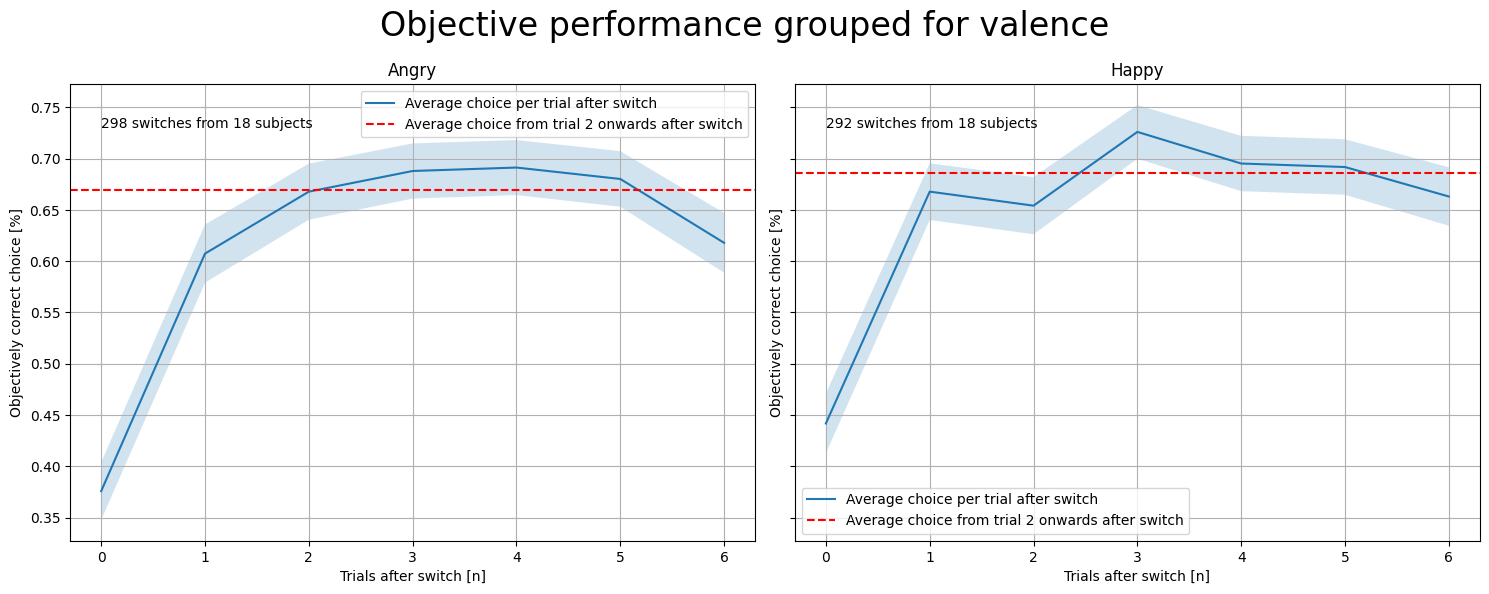

In [17]:
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = objectively_correct_answers_per_switch_block.set_index('stimuli_type')

subject_counts = len(df['subject_id'].unique())

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id'])

# Count the number of times both conditions were shown
group_counts = df.index.value_counts()

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby('stimuli_type').mean()
means_overall = means.iloc[:, 2:]
average_choice_after_switch_total = means_overall.mean(axis=1).tolist()
stds = df.groupby('stimuli_type').sem()

# Plotting
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 6), sharex=False, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

fig.suptitle('Objective performance grouped for valence', fontsize=24, y=0.982)

stimuli_types_list = ['Angry', 'Happy']

stimuli_types = means.index
for i, stimuli_type in enumerate(stimuli_types):
    # Timepoints are the column names converted to integers for x-axis values
    timepoints = np.arange(len(means.columns))
    mean_values = means.loc[stimuli_type]
    std_values = stds.loc[stimuli_type]

    axs[i].plot(timepoints, mean_values, label='Average choice per trial after switch')
    axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
    axs[i].axhline((average_choice_after_switch_total[i]), color='r', linestyle='--', label='Average choice from trial 2 onwards after switch')
    axs[i].set_title(stimuli_types_list[i])
    axs[i].set_xlabel('Trials after switch [n]')
    axs[i].set_ylabel('Objectively correct choice [%]')
    axs[i].text(0, 0.73, f'{group_counts[stimuli_type]} switches from {subject_counts} subjects', fontsize=10)
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objective_performance_grouped_for_valence_0-12.pdf'))
plt.show()

# Now the same but split for congruency and valence

In [18]:
# Create new plots with different intervals that also contain the 50% trials
mapping = {0: 'subject_id', 1: 'stimuli_type', 2: 'congruency', 3: 0, 4: 1, 5: 2, 6: 3, 7: 4, 8: 5, 9: 6}#, 10: 7, 11: 8, 12: 9, 13: 10}
group_name = 'congruency'
unique_group_types = combined_results_dataframe[group_name].unique()


all_switches_dataframe = analysis_functions.find_switches_in_dataframe(combined_results_dataframe,
                                                                             unique_subject_ids, unique_stimuli_types,
                                                                             'congruency', plot_range, mapping)
print(all_switches_dataframe)

     subject_id  trial  stimuli_type  probability_condition switch  \
9        sub-02      9             1                     20  False   
10       sub-02     10             1                     20  False   
14       sub-02     14             1                     20  False   
15       sub-02     15             1                     20  False   
16       sub-02     16             1                     20  False   
...         ...    ...           ...                    ...    ...   
8126     sub-21    442             3                     80  False   
8128     sub-21    444             3                     80  False   
8130     sub-21    446             3                     80  False   
8132     sub-21    448             3                     80  False   
8133     sub-21    449             3                     80  False   

       congruency  
9     incongruent  
10    incongruent  
14    incongruent  
15    incongruent  
16    incongruent  
...           ...  
8126  incongruent  

c:\Users\marti\git\RL_task\analysis\analysis_functions.py:612: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  input_dataframe['switch'].iloc[0] = 'False'
c:\Users\marti\git\RL_task\analysis\analysis_functions.py:612: SettingWithCopyWarning: 


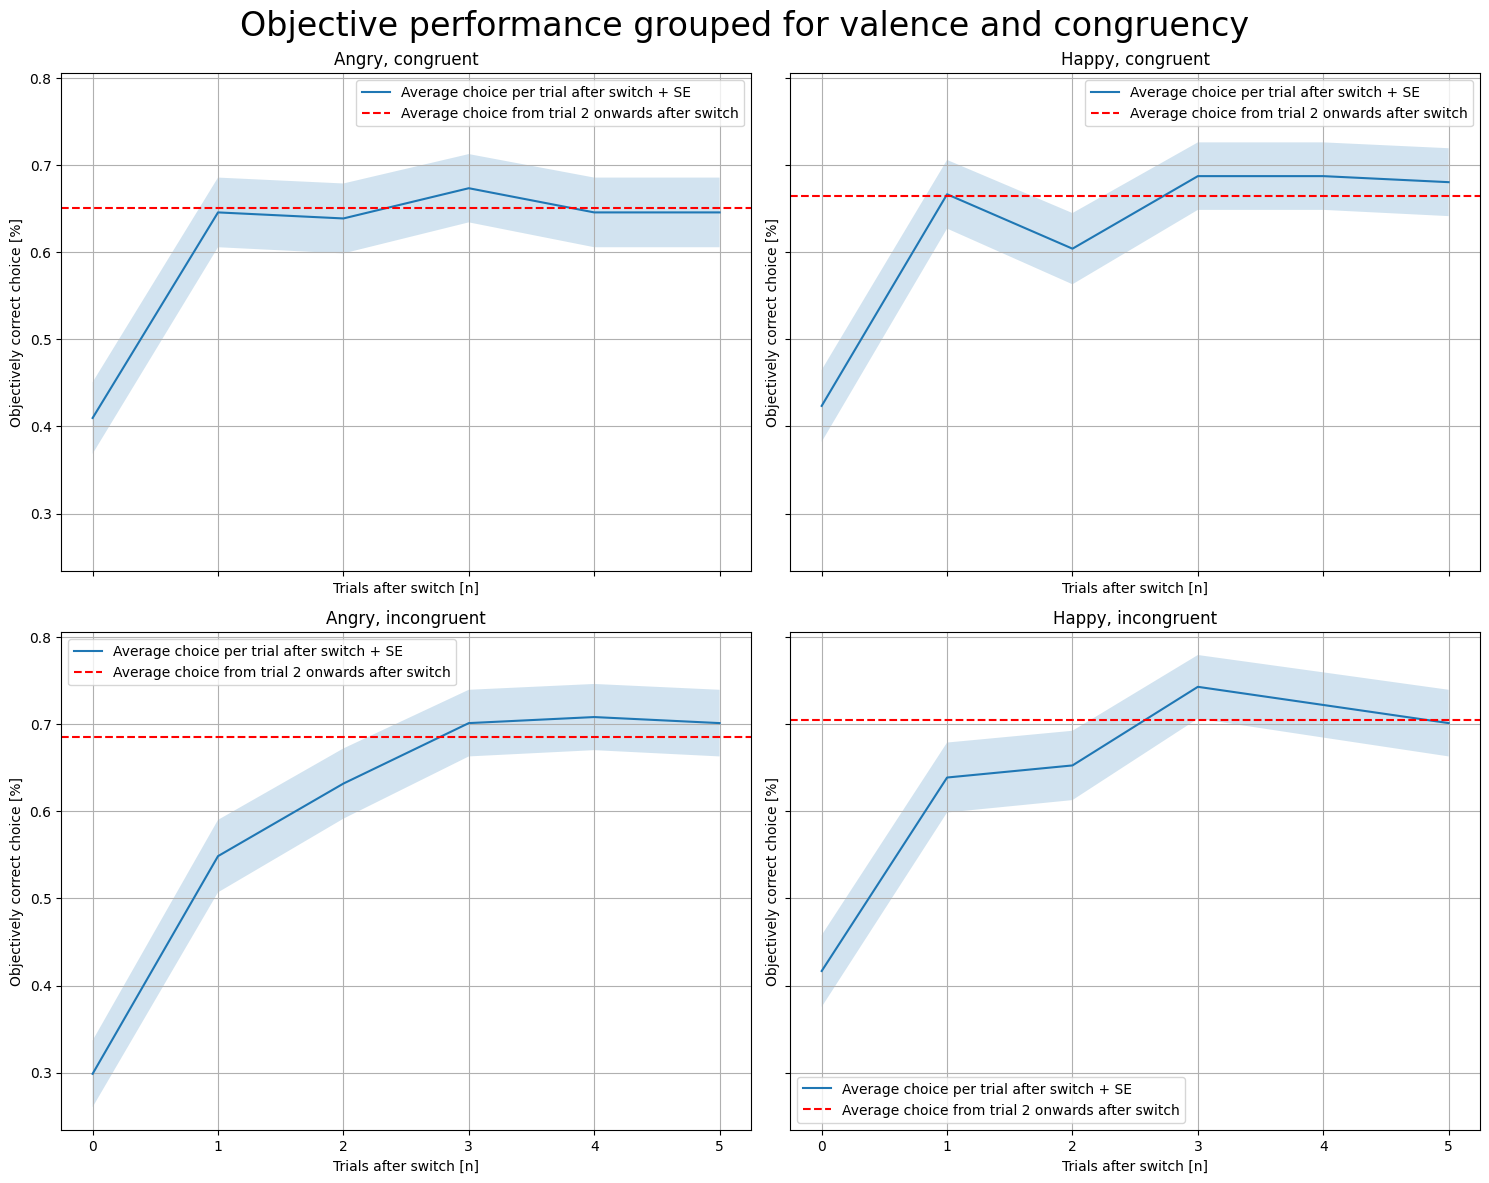

In [19]:
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = all_switches_dataframe

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby(['congruency', 'stimuli_type']).mean()
means_overall = means.iloc[:, 2:]
average_choice_after_switch_total = means_overall.mean(axis=1).tolist()

stds = df.groupby(['congruency', 'stimuli_type']).sem()

# Plotting
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(15, 12), sharex=True, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

fig.suptitle('Objective performance grouped for valence and congruency', fontsize=24, y=0.982)

congruency_list = df['congruency'].unique()
stimuli_list = df['stimuli_type'].unique()
stimuli_types_list = ['Angry', 'Angry', 'Happy', 'Happy']

congruency_types = means.index
for i, congruency_type in enumerate(congruency_types):
    # Timepoints are the column names converted to integers for x-axis values
    timepoints = list(range(plot_range[0], plot_range[1]))
    mean_values = means.loc[congruency_type]
    std_values = stds.loc[congruency_type]

    axs[i].plot(timepoints, mean_values, label='Average choice per trial after switch + SE')
    axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
    axs[i].axhline((average_choice_after_switch_total[i]), color='r', linestyle='--', label='Average choice from trial 2 onwards after switch')
    #axs[i].plot(probability_dataframe_pivoted[i+1].dropna())
    axs[i].set_title(f'{stimuli_types_list[congruency_type[1]]}, {congruency_type[0]}')
    axs[i].set_xlabel('Trials after switch [n]')
    axs[i].set_ylabel('Objectively correct choice [%]')
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objective_performance_grouped_for_valence_and_congruency.pdf'))
plt.show()

In [20]:
print(df)

0   stimuli_type   congruency  0  1  2  3  4  5
1              1    congruent  1  1  1  0  1  1
2              1  incongruent  1  1  1  1  1  1
3              1    congruent  1  1  0  1  1  1
4              1  incongruent  1  1  1  1  1  0
5              1    congruent  1  1  1  1  1  1
..           ...          ... .. .. .. .. .. ..
572            3  incongruent  1  0  0  1  1  1
573            3    congruent  0  1  0  1  1  1
574            3  incongruent  0  0  0  1  1  0
575            3    congruent  0  0  0  0  1  1
576            3  incongruent  0  0  1  1  0  1

[576 rows x 8 columns]


# Plotting just the responses
As a check to see if giving the two types of responses was equally as difficult

In [21]:
# Create new plots with different intervals that also contain the 50% trials
mapping = {0: 'subject_id', 1: 'stimuli_type', 2: 'response', 3: 0, 4: 1, 5: 2, 6: 3, 7: 4, 8: 5, 9: 6, 10: 7, 11: 8, 12: 9, 13: 10}
group_name = 'response'
unique_group_types = combined_results_dataframe[group_name].unique()


all_switches_dataframe = analysis_functions.find_switches_in_dataframe(combined_results_dataframe,
                                                                             unique_subject_ids, unique_stimuli_types,
                                                                             group_name, plot_range, mapping)
print(all_switches_dataframe)

     subject_id  trial  stimuli_type  probability_condition switch response
9        sub-02      9             1                     20  False      NaN
10       sub-02     10             1                     20  False       up
14       sub-02     14             1                     20  False     down
15       sub-02     15             1                     20  False     down
16       sub-02     16             1                     20  False     down
...         ...    ...           ...                    ...    ...      ...
8126     sub-21    442             3                     80  False     down
8128     sub-21    444             3                     80  False       up
8130     sub-21    446             3                     80  False       up
8132     sub-21    448             3                     80  False     down
8133     sub-21    449             3                     80  False       up

[7992 rows x 6 columns]
0   subject_id stimuli_type response  0  1  2  3  4  5
1       

c:\Users\marti\git\RL_task\analysis\analysis_functions.py:612: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  input_dataframe['switch'].iloc[0] = 'False'
c:\Users\marti\git\RL_task\analysis\analysis_functions.py:612: SettingWithCopyWarning: 


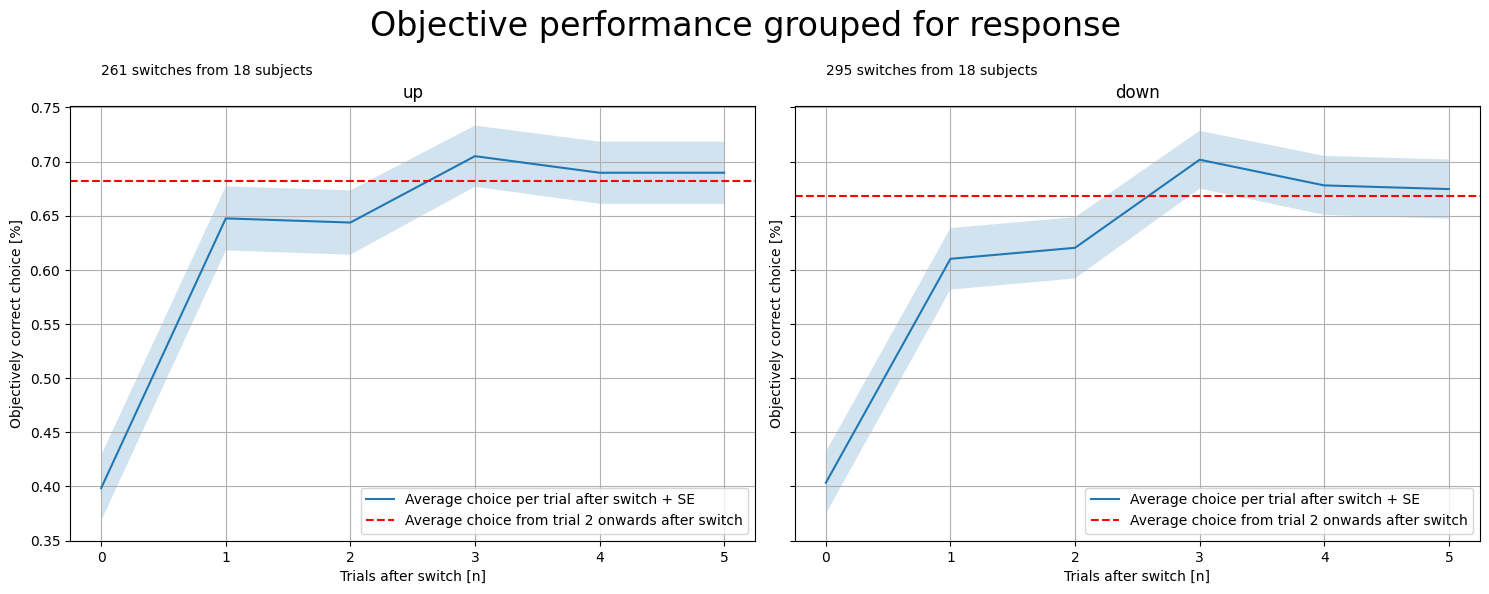

In [22]:
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = all_switches_dataframe

subject_counts = len(df['subject_id'].unique())

# Count the number of times both conditions were shown
group_counts = df['response'].value_counts()

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id'])
df = df.drop(columns=['stimuli_type'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby(['response']).mean()
means_overall = means.iloc[:, 2:]
average_choice_after_switch_total = means_overall.mean(axis=1).tolist()

stds = df.groupby(['response']).sem()

# Plotting
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 6), sharex=True, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

fig.suptitle('Objective performance grouped for response', fontsize=24, y=0.982)

congruency_list = df['response'].unique()

congruency_types = means.index
for i, congruency_type in enumerate(congruency_types):
    # Timepoints are the column names converted to integers for x-axis values
    timepoints = list(range(plot_range[0], plot_range[1]))
    mean_values = means.loc[congruency_type]
    std_values = stds.loc[congruency_type]

    axs[i].plot(timepoints, mean_values, label='Average choice per trial after switch + SE')
    axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
    axs[i].axhline((average_choice_after_switch_total[i]), color='r', linestyle='--', label='Average choice from trial 2 onwards after switch')
    #axs[i].plot(probability_dataframe_pivoted[i+1].dropna())
    axs[i].set_title(f'{congruency_list[i]}')
    axs[i].set_xlabel('Trials after switch [n]')
    axs[i].set_ylabel('Objectively correct choice [%]')
    axs[i].text(0, 0.78, f'{group_counts[congruency_type]} switches from {subject_counts} subjects', fontsize=10)
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objective_performance_grouped_for_response.pdf'))
plt.show()

# Now plot subplots for the responses and congruency
To see whether giving one type of response interacted with congruency, also as a check

In [23]:
# Create new plots with different intervals that also contain the 50% trials
group_name_1 = 'congruency'
group_name_2 = 'response'
initial_columns = {0: 'stimuli_type', 1: 'subject_id', 2: group_name_2, 3: group_name_1}
# Append the plot range to the existing dictionary
mapping = initial_columns.copy()
mapping.update({k+4: v for k, v in enumerate(plot_range)})

dataframe = analysis_functions.find_switches_in_dataframe(combined_results_dataframe,
                                                                             unique_subject_ids, unique_stimuli_types,
                                                                             group_name_1, plot_range, mapping, group_name_2)
print(dataframe)

     subject_id  trial  stimuli_type  probability_condition switch  \
9        sub-02      9             1                     20  False   
10       sub-02     10             1                     20  False   
14       sub-02     14             1                     20  False   
15       sub-02     15             1                     20  False   
16       sub-02     16             1                     20  False   
...         ...    ...           ...                    ...    ...   
8126     sub-21    442             3                     80  False   
8128     sub-21    444             3                     80  False   
8130     sub-21    446             3                     80  False   
8132     sub-21    448             3                     80  False   
8133     sub-21    449             3                     80  False   

       congruency response  
9     incongruent      NaN  
10    incongruent       up  
14    incongruent     down  
15    incongruent     down  
16    incongru

c:\Users\marti\git\RL_task\analysis\analysis_functions.py:612: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  input_dataframe['switch'].iloc[0] = 'False'
c:\Users\marti\git\RL_task\analysis\analysis_functions.py:612: SettingWithCopyWarning: 


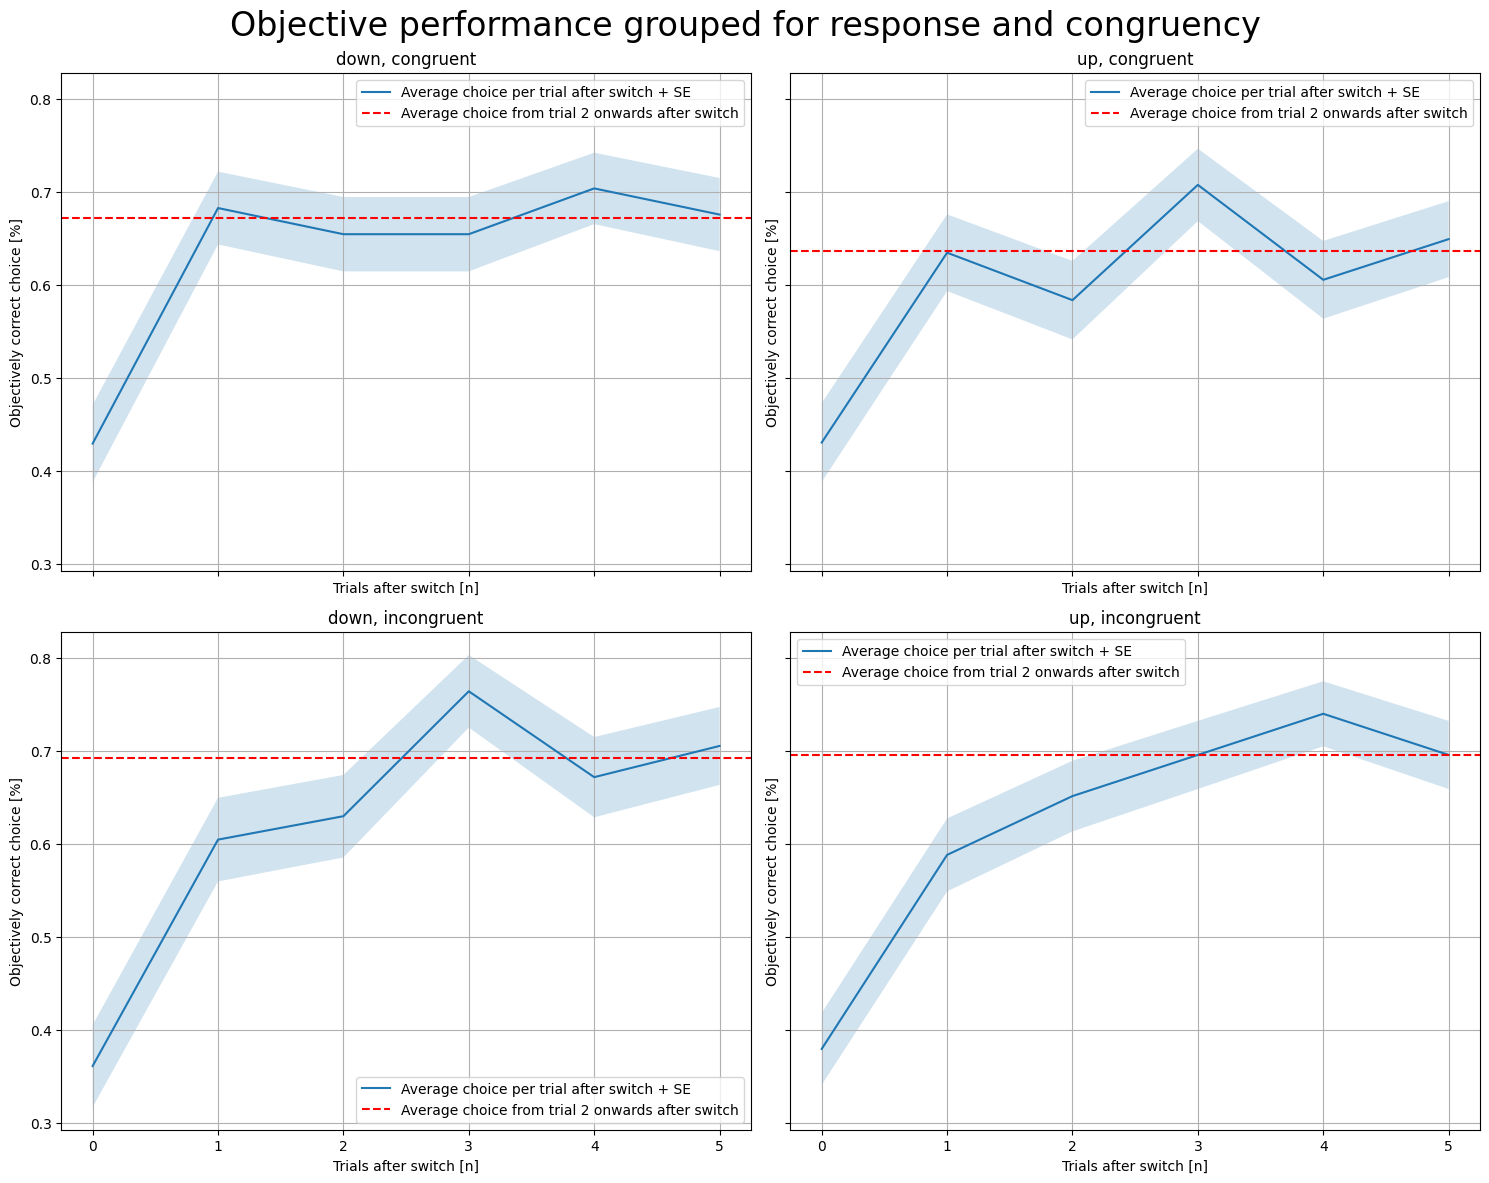

In [24]:
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = dataframe

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id', 'stimuli_type'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby(['congruency', 'response']).mean()
means_overall = means.iloc[:, 2:]
average_choice_after_switch_total = means_overall.mean(axis=1).tolist()

stds = df.groupby(['congruency', 'response']).sem()

# Plotting
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(15, 12), sharex=True, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

fig.suptitle('Objective performance grouped for response and congruency', fontsize=24, y=0.982)

congruency_list = df['congruency'].unique()
volatility_list = df['response'].unique()

congruency_types = means.index
for i, congruency_type in enumerate(congruency_types):
    # Timepoints are the column names converted to integers for x-axis values
    timepoints = list(range(plot_range[0], plot_range[1]))
    mean_values = means.loc[congruency_type]
    std_values = stds.loc[congruency_type]

    axs[i].plot(timepoints, mean_values, label='Average choice per trial after switch + SE')
    axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
    axs[i].axhline((average_choice_after_switch_total[i]), color='r', linestyle='--', label='Average choice from trial 2 onwards after switch')
    #axs[i].plot(probability_dataframe_pivoted[i+1].dropna())
    axs[i].set_title(f'{congruency_type[1]}, {congruency_type[0]}')
    axs[i].set_xlabel('Trials after switch [n]')
    axs[i].set_ylabel('Objectively correct choice [%]')
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objective_performance_grouped_for_response_and_congruency.pdf'))
plt.show()

## objectively correct answers without binning
Now we'll look at the objectively correct answers in a sequential manner, so without binning them based on switches in reward contingencies.
Plot probability of correct response on Y-axis to trials on X-axis

In [25]:
# Take the mean from all 12 trials after each switch
trials_after_switch_to_plot = list(range(0,7))
intermediate_dataframe = objectively_correct_answers_per_switch_block
intermediate_dataframe['switch_number'] = intermediate_dataframe.groupby(['subject_id','stimuli_type']).cumcount()
print(intermediate_dataframe)

# Preparation for loop
unique_switches = intermediate_dataframe['switch_number'].unique()
column_names = ['stimuli_type', 'switch'] + trials_after_switch_to_plot
objectively_correct_answers_averaged_per_switch_block = pd.DataFrame(columns = column_names)

# Loop through each stimulus and switch type
for index_stimuli, value_stimuli in enumerate(unique_stimuli_types):
    for index_switch, value_switch in enumerate(unique_switches):
        filtered_dataframe = intermediate_dataframe[(intermediate_dataframe['stimuli_type'] == value_stimuli) & (intermediate_dataframe['switch_number'] == value_switch)]
        list_with_averages = [value_stimuli, value_switch] + (filtered_dataframe[trials_after_switch_to_plot].mean()).to_list()
        objectively_correct_answers_averaged_per_switch_block.loc[len(objectively_correct_answers_averaged_per_switch_block)] = list_with_averages

    subject_id  stimuli_type  0  1  2  3  4    5    6  switch_number
0       sub-02             3  1  0  1  1  1  0.0  1.0              0
1       sub-02             3  1  1  0  0  1  1.0  0.0              1
2       sub-02             3  0  1  1  1  1  1.0  1.0              2
3       sub-02             3  1  1  1  0  1  1.0  1.0              3
4       sub-02             3  1  1  1  1  0  0.0  1.0              4
..         ...           ... .. .. .. .. ..  ...  ...            ...
585     sub-21             1  1  0  0  0  0  0.0  0.0             11
586     sub-21             1  0  0  1  0  1  0.0  0.0             12
587     sub-21             1  1  1  1  0  1  1.0  0.0             13
588     sub-21             1  0  0  1  1  1  0.0  1.0             14
589     sub-21             1  0  1  0  0  1  0.0  NaN             15

[590 rows x 10 columns]


In [26]:
print(stimuli_types_list)
print(stimuli_types)

['Angry', 'Angry', 'Happy', 'Happy']
Index([1, 3], dtype='int64', name='stimuli_type')


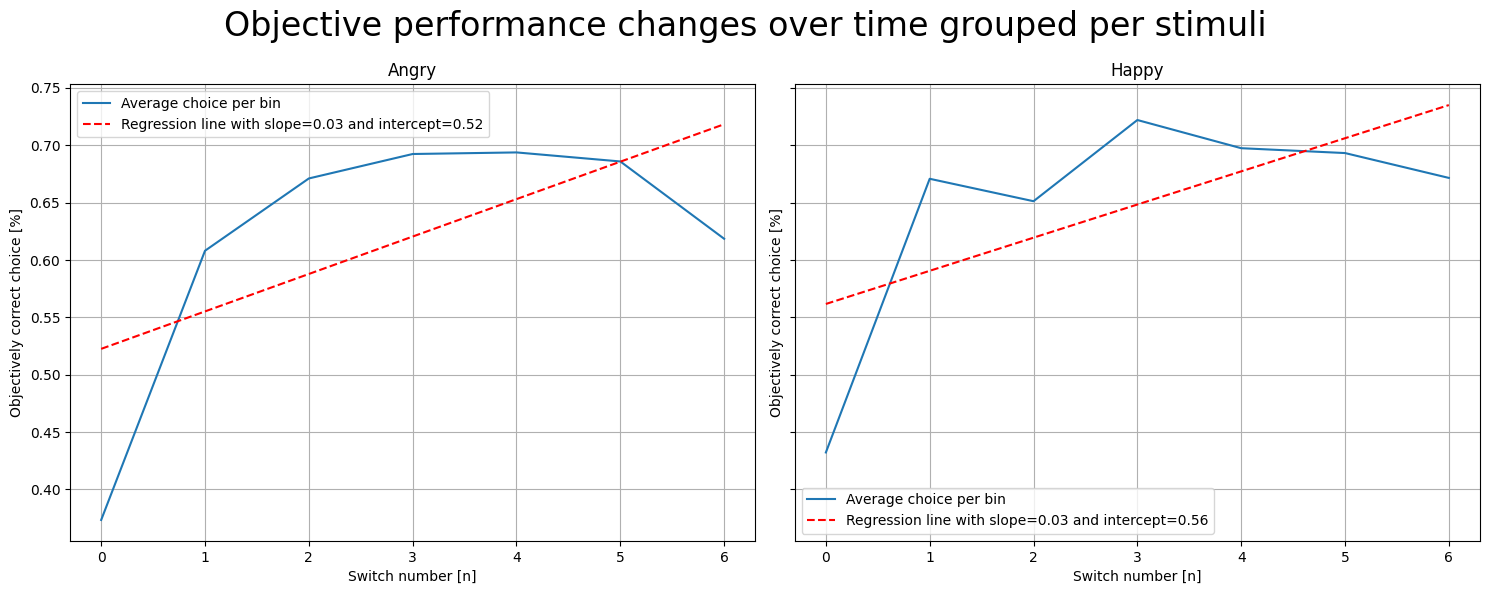

In [27]:
# Plotting
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 6), sharex=False, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

fig.suptitle('Objective performance changes over time grouped per stimuli', fontsize=24, y=0.982)

for index_stimuli, value_stimuli in enumerate(stimuli_types):
    # Timepoints are the column names converted to integers for x-axis values
    filtered_dataframe = objectively_correct_answers_averaged_per_switch_block[objectively_correct_answers_averaged_per_switch_block['stimuli_type'] == value_stimuli]
    filtered_dataframe = filtered_dataframe.drop(['stimuli_type', 'switch'], axis=1)

    timepoints = [int(col) for col in filtered_dataframe.columns]
    averages = filtered_dataframe.mean()
    a, b = np.polyfit(timepoints, averages, 1)
    regression_line = [i * a + b for i in timepoints]

    axs[index_stimuli].plot(averages, label='Average choice per bin')
    axs[index_stimuli].plot(timepoints, regression_line, color='r', linestyle='--', label=f'Regression line with slope={a:.2f} and intercept={b:.2f}')
    axs[index_stimuli].set_title(stimuli_types_list[index_stimuli+1])
    axs[index_stimuli].set_xlabel('Switch number [n]')
    axs[index_stimuli].set_ylabel('Objectively correct choice [%]')
    axs[index_stimuli].legend()
    axs[index_stimuli].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objective_performance_changes_over_time_grouped_per_stimuli.pdf'))
plt.show()

# Objectively correct answers binned around a switch
Starting 12 trials before the switch and ending 4 after.

In [28]:
# Create new plots with different intervals that also contain the 50% trials
objectively_correct_answers_per_switch_block = pd.DataFrame()
adjusted_plot_range = [plot_range[0] - plot_range[1] + 1, plot_range[1]]

all_switches_dataframe = analysis_functions.find_switches_in_dataframe(combined_results_dataframe,
                                                                             unique_subject_ids, unique_stimuli_types,
                                                                             group_name, adjusted_plot_range, mapping)
print(all_switches_dataframe)

'''
for index_stimuli in unique_stimuli_types:
    for index_subject_id in unique_subject_ids:
        combined_results_grouped_dataframe = combined_results_dataframe[(combined_results_dataframe['stimuli_type'] == index_stimuli) & (combined_results_dataframe['subject_id'] == index_subject_id)]

        # Add column that notes if a switch occurred recently
        combined_results_grouped_dataframe['switch'] = combined_results_grouped_dataframe['probability_condition'].diff().ne(0)
        # Filter out trials with 50% reward probability
        dataframe_containing_groups_filtered = combined_results_grouped_dataframe.reset_index()
        dataframe_containing_groups_filtered = dataframe_containing_groups_filtered.drop(dataframe_containing_groups_filtered[(dataframe_containing_groups_filtered.probability_condition == 50) | (dataframe_containing_groups_filtered.objectively_correct == 'Late')].index, inplace=False)

        # Add switches to a list
        switches_reward = dataframe_containing_groups_filtered.index[dataframe_containing_groups_filtered['switch'] == True].tolist()

        for index_switches, values in enumerate(switches_reward):
            switches_dataframe = combined_results_grouped_dataframe.iloc[values-10:values+5]
            objectively_correct_after_switch = [index_subject_id, index_stimuli]
            objectively_correct_after_switch.extend(switches_dataframe['objectively_correct_boolean'].tolist())
            objectively_correct_after_switch = pd.DataFrame([objectively_correct_after_switch])
            objectively_correct_answers_per_switch_block = pd.concat([objectively_correct_answers_per_switch_block, objectively_correct_after_switch])
            row_index = row_index + 1

objectively_correct_answers_per_switch_block = objectively_correct_answers_per_switch_block.reset_index(drop = True)
objectively_correct_answers_per_switch_block = objectively_correct_answers_per_switch_block.rename(columns={0: 'subject_id', 1: 'stimuli_type', 2: -10, 3: -9, 4: -8, 5: -7, 6: -6, 7: -5, 8: -4, 9: -3, 10: -2, 11: -1, 12: 0, 13: 1, 14: 2, 15: 3, 16: 4})
'''

     subject_id  trial  stimuli_type  probability_condition switch response
9        sub-02      9             1                     20  False      NaN
10       sub-02     10             1                     20  False       up
14       sub-02     14             1                     20  False     down
15       sub-02     15             1                     20  False     down
16       sub-02     16             1                     20  False     down
...         ...    ...           ...                    ...    ...      ...
8126     sub-21    442             3                     80  False     down
8128     sub-21    444             3                     80  False       up
8130     sub-21    446             3                     80  False       up
8132     sub-21    448             3                     80  False     down
8133     sub-21    449             3                     80  False       up

[7992 rows x 6 columns]
0   subject_id stimuli_type response  -5  -4  -3  -2  -1  0  1 

c:\Users\marti\git\RL_task\analysis\analysis_functions.py:612: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  input_dataframe['switch'].iloc[0] = 'False'
c:\Users\marti\git\RL_task\analysis\analysis_functions.py:612: SettingWithCopyWarning: 


"\nfor index_stimuli in unique_stimuli_types:\n    for index_subject_id in unique_subject_ids:\n        combined_results_grouped_dataframe = combined_results_dataframe[(combined_results_dataframe['stimuli_type'] == index_stimuli) & (combined_results_dataframe['subject_id'] == index_subject_id)]\n\n        # Add column that notes if a switch occurred recently\n        combined_results_grouped_dataframe['switch'] = combined_results_grouped_dataframe['probability_condition'].diff().ne(0)\n        # Filter out trials with 50% reward probability\n        dataframe_containing_groups_filtered = combined_results_grouped_dataframe.reset_index()\n        dataframe_containing_groups_filtered = dataframe_containing_groups_filtered.drop(dataframe_containing_groups_filtered[(dataframe_containing_groups_filtered.probability_condition == 50) | (dataframe_containing_groups_filtered.objectively_correct == 'Late')].index, inplace=False)\n\n        # Add switches to a list\n        switches_reward = dataf

In [29]:
'''
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = all_switches_dataframe.set_index('stimuli_type')

subject_counts = len(df['subject_id'].unique())

# Count the number of times both conditions were shown
group_counts = df.index.value_counts()

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby('stimuli_type').mean()
average_choice_after_switch_total = means.mean(axis=1).tolist()
stds = df.groupby('stimuli_type').sem()

# Plotting
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 6), sharex=False, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

fig.suptitle('Objective performance grouped per stimuli', fontsize=24, y=0.982)

stimuli_types_list = ['Angry', 'Happy']

stimuli_types = means.index
for i, stimuli_type in enumerate(stimuli_types):
    # Timepoints are the column names converted to integers for x-axis values
    timepoints = list(range(adjusted_plot_range[0], adjusted_plot_range[1]))
    mean_values = means.loc[stimuli_type]
    std_values = stds.loc[stimuli_type]

    axs[i].plot(timepoints, mean_values, label='Average choice per trial after switch')
    axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
    #axs[i].axhline((average_choice_after_switch_total[i]), color='r', linestyle='--', label='Average choice after switch')
    #axs[i].plot(probability_dataframe_pivoted[i+1].dropna())
    axs[i].set_title(stimuli_types_list[i])
    axs[i].set_xlabel('Trials after switch [n]')
    axs[i].set_ylabel('Objectively correct choice [%]')
    axs[i].text(0, 0.78, f'{group_counts[stimuli_type]} switches from {subject_counts} subjects', fontsize=10)
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objective_performance_grouped_per_stimuli_binned_around_switch.pdf'))
plt.show()
'''

"\n# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily\ndf = all_switches_dataframe.set_index('stimuli_type')\n\nsubject_counts = len(df['subject_id'].unique())\n\n# Count the number of times both conditions were shown\ngroup_counts = df.index.value_counts()\n\n# We are not using 'subject_id', so let's exclude it from our calculations\ndf = df.drop(columns=['subject_id'])\n\n# Calculate the mean and standard deviation for each timepoint and stimuli_type\nmeans = df.groupby('stimuli_type').mean()\naverage_choice_after_switch_total = means.mean(axis=1).tolist()\nstds = df.groupby('stimuli_type').sem()\n\n# Plotting\nfig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 6), sharex=False, sharey=True) # Adjust based on the number of stimuli_types\naxs = axs.flatten() # Flatten to iterate easily\n\nfig.suptitle('Objective performance grouped per stimuli', fontsize=24, y=0.982)\n\nstimuli_types_list = ['Angry', 'Happy']\n\nstimuli_types = means.index\nfor i, stimuli_t

# Subplots for incongruent and congruent switches

In [30]:
# Create new plots with different intervals that also contain the 50% trials
mapping = {0: 'subject_id', 1: 'stimuli_type', 2: 'congruency', 3: 0, 4: 1, 5: 2, 6: 3, 7: 4, 8: 5, 9: 6}#, 10: 7, 11: 8, 12: 9, 13: 10}
group_name = 'congruency'
unique_group_types = combined_results_dataframe[group_name].unique()


all_switches_dataframe = analysis_functions.find_switches_in_dataframe(combined_results_dataframe,
                                                                             unique_subject_ids, unique_stimuli_types,
                                                                             group_name, plot_range, mapping)
print(all_switches_dataframe)

     subject_id  trial  stimuli_type  probability_condition switch  \
9        sub-02      9             1                     20  False   
10       sub-02     10             1                     20  False   
14       sub-02     14             1                     20  False   
15       sub-02     15             1                     20  False   
16       sub-02     16             1                     20  False   
...         ...    ...           ...                    ...    ...   
8126     sub-21    442             3                     80  False   
8128     sub-21    444             3                     80  False   
8130     sub-21    446             3                     80  False   
8132     sub-21    448             3                     80  False   
8133     sub-21    449             3                     80  False   

       congruency  
9     incongruent  
10    incongruent  
14    incongruent  
15    incongruent  
16    incongruent  
...           ...  
8126  incongruent  

c:\Users\marti\git\RL_task\analysis\analysis_functions.py:612: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  input_dataframe['switch'].iloc[0] = 'False'
c:\Users\marti\git\RL_task\analysis\analysis_functions.py:612: SettingWithCopyWarning: 


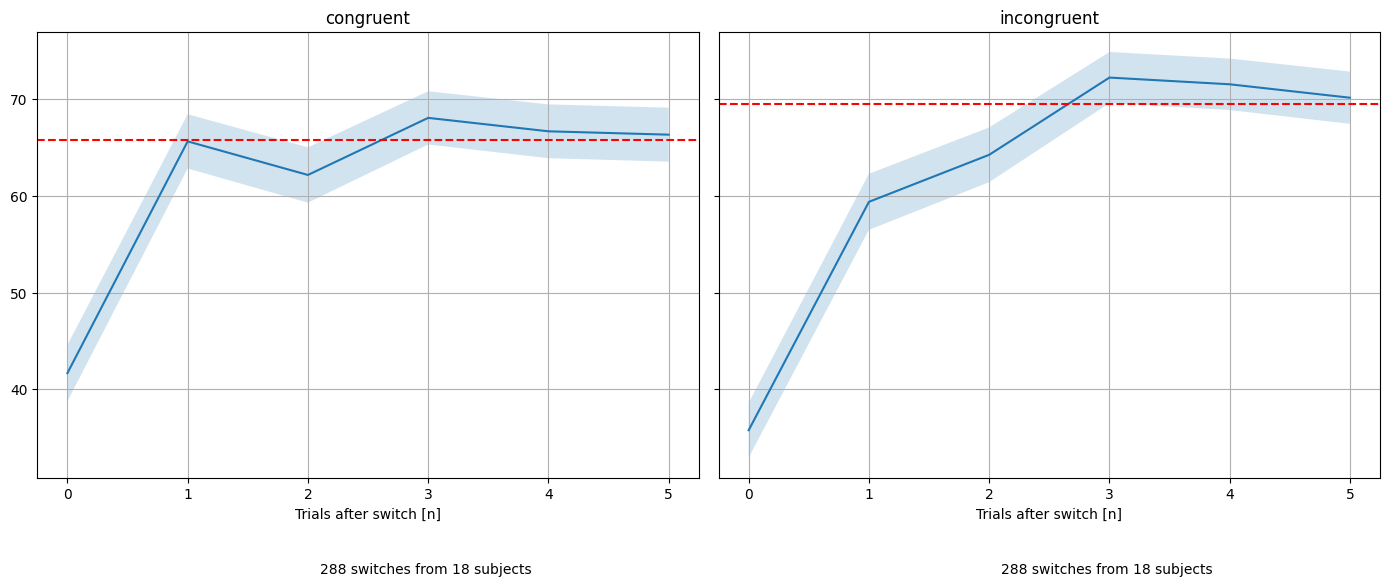

In [31]:
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = all_switches_dataframe.set_index('congruency')

subject_counts = len(df['subject_id'].unique())

# Count the number of times both conditions were shown
group_counts = df.index.value_counts()

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id'])
df = df.drop(columns=['stimuli_type'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby('congruency').mean()
means = means*100
means_overall = means.iloc[:, 2:]
average_choice_after_switch_total = means_overall.mean(axis=1).tolist()
stds = df.groupby('congruency').sem()
stds = stds * 100

# Plotting
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(14, 6), sharex=False, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

#fig.suptitle('Objective performance grouped for congruency', fontsize=24, y=0.982)

congruency_list = all_switches_dataframe['congruency'].unique()

congruency_types = means.index
for i, congruency_type in enumerate(congruency_types):
    # Timepoints are the column names converted to integers for x-axis values
    timepoints = list(range(plot_range[0], plot_range[1]))
    mean_values = means.loc[congruency_type]
    std_values = stds.loc[congruency_type]

    axs[i].plot(timepoints, mean_values, label='Average choice per trial after switch + SE')
    axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
    axs[i].axhline((average_choice_after_switch_total[i]), color='r', linestyle='--', label='Average choice from trial 2 onwards after switch')
    #axs[i].plot(probability_dataframe_pivoted[i+1].dropna())
    axs[i].set_title(congruency_type)
    axs[i].set_xlabel('Trials after switch [n]')
    #axs[i].set_ylabel('Objectively correct choice [%]')
    axs[i].text(2.1, 21, f'{group_counts[congruency_type]} switches from {subject_counts} subjects', fontsize=10) #81
    #axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objective_performance_grouped_for_congruency.pdf'))
plt.show()

# Time before stabilisation
This will be the amount of trials before participants reach an average response of x%

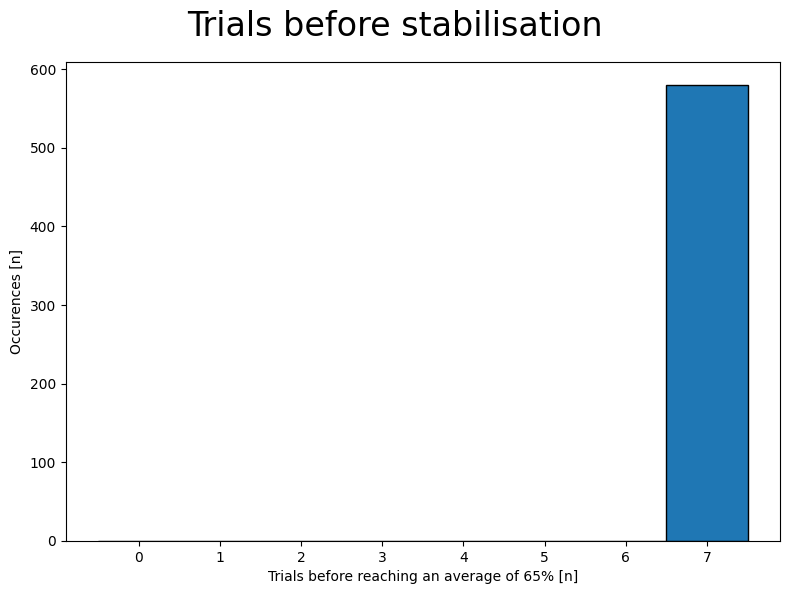

In [32]:
# Set some plotting guidelines
stable_performance = 65
sequence_bin_range = range(min(plot_range), max(plot_range) + 3)
sequence_tick_range = range(min(plot_range), max(plot_range) + 2)

# Create subplots
fig, axes = plt.subplots(figsize=(8, 6), sharey=True)

fig.suptitle('Trials before stabilisation', fontsize=24, y=0.982)

# Bin edges centered around the ticks
bin_edges = [i - 0.5 for i in sequence_bin_range]

# Plot for switch value 1.0
reversal_results = analysis_functions.trials_before_stabilisation(combined_results_dataframe, stable_performance, plot_range, 1.0)
axes.hist(reversal_results['number_of_trials_before_stabilising'], bins=bin_edges, edgecolor='black')
#axes.set_title(reversal_list[0])
axes.set_xlabel(f'Trials before reaching an average of {stable_performance}% [n]')
axes.set_ylabel('Occurences [n]')
axes.set_xticks(sequence_tick_range)

ticks = axes.get_xticks()
tick_labels = axes.get_xticklabels()

# Replace the label at position 13 with None
tick_labels = [label.get_text() if tick != 13 else 'None' for tick, label in zip(ticks, tick_labels)]

# Set the new tick labels
axes.set_xticklabels(tick_labels)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objective_performance_trials_before_stabilisation.pdf'))
plt.show()

# Chance of a forward response around switch
Here, we plot the chance of a forward response around a switch, hoping to capture a flip in the switch for the four categories:
- happy incongruent > congruent
- angry incongruent > congruent
- happy congruent > incongruent
- angry congruent > incongruent

In [33]:
# First create a new dataframe with the 
adjusted_plot_range = [plot_range[0] - plot_range[1], plot_range[1]]
dataframe = analysis_functions.bin_responses_for_congruency(combined_results_dataframe, adjusted_plot_range) 

print(dataframe)

c:\Users\marti\git\RL_task\analysis\analysis_functions.py:187: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dataframe[new_column] = dataframe[old_column].replace(mapping)


[5, 11, 21, 31, 39, 49, 81, 113, 122, 128, 135, 143, 151, 156, 184, 212, 218, 224, 230, 240, 250, 258, 268, 300, 331, 341, 347, 355, 363, 371, 377, 404, 432, 443, 451, 457, 465, 470, 480, 508, 540, 546, 554, 564, 574, 582, 592, 619, 651, 657, 663, 671, 675, 683, 689, 699, 726, 758, 764, 772, 782, 792, 799, 809, 837, 869, 880, 888, 894, 904, 914, 922, 950, 981, 988, 994, 1002, 1012, 1018, 1028, 1055, 1087, 1093, 1099, 1107, 1113, 1123, 1132, 1139, 1167, 1199, 1207, 1213, 1221, 1231, 1237, 1247, 1273, 1305, 1311, 1342, 1372, 1382, 1386, 1396, 1404, 1410, 1419, 1447, 1474, 1482, 1491, 1497, 1505, 1513, 1519, 1525, 1554, 1594, 1600, 1609, 1616, 1622, 1631, 1659, 1686, 1694, 1704, 1717, 1725, 1731, 1764, 1791, 1798, 1806, 1814, 1820, 1830, 1838, 1870, 1900, 1906, 1916, 1926, 1932, 1938, 1948, 1953, 1981, 2009, 2017, 2025, 2033, 2039, 2056, 2088, 2120, 2126, 2136, 2146, 2152, 2158, 2168, 2194, 2221, 2229, 2237, 2243, 2253, 2257, 2265, 2295, 2325, 2333, 2339, 2347, 2356, 2362, 2372, 2378, 240

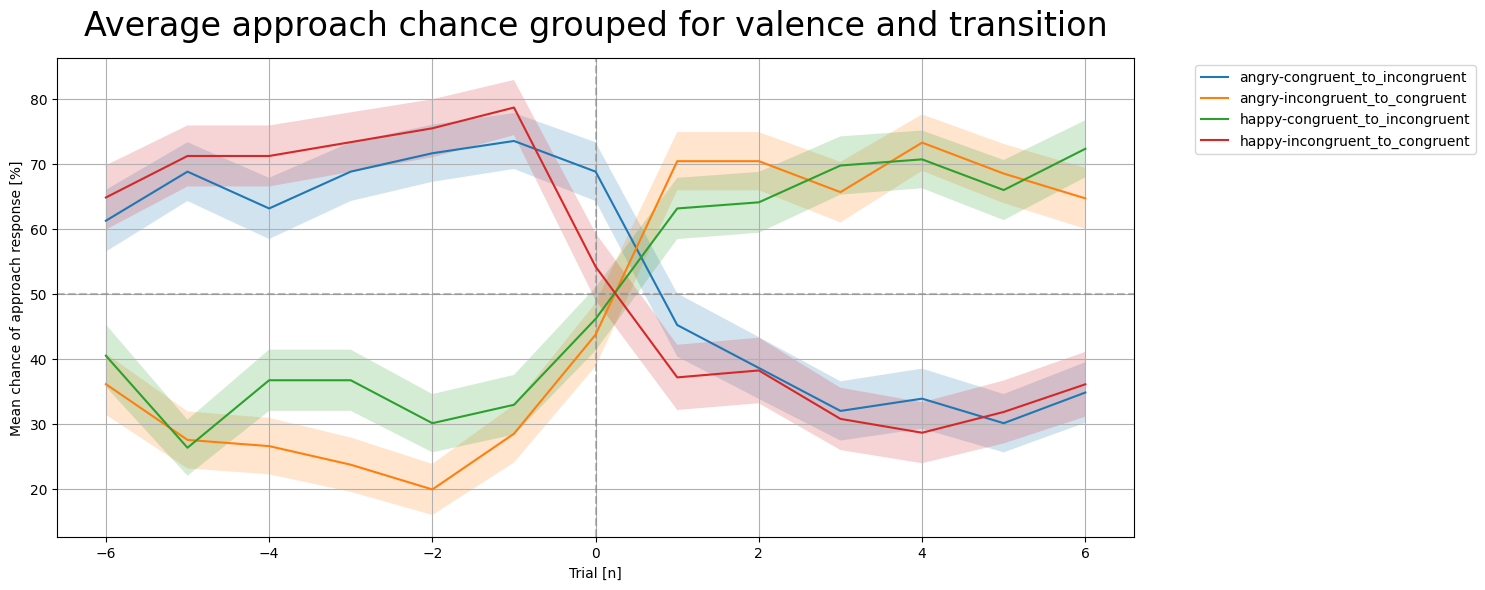

In [34]:
# Group the data
grouped_dataframe = dataframe.groupby(['trials_around_switch', 'emotional_valence', 'transition'])['response_int'].agg(['mean', 'sem']).reset_index()

# Plotting with Matplotlib
plt.figure(figsize=(15, 6))

# Define the unique groups for 'emotional_valence' and 'transition'
emotional_valences = grouped_dataframe['emotional_valence'].unique()
transitions = grouped_dataframe['transition'].unique()
transitions = transitions[transitions != 'no_transition']

# Plot each group
plt.axhline(50, color='grey', linestyle='dashed', alpha=0.5)
plt.axvline(0, color='grey', linestyle='dashed', alpha=0.5)
for valence in emotional_valences:
    for transition in transitions:
        subset = grouped_dataframe[(grouped_dataframe['emotional_valence'] == valence) & (grouped_dataframe['transition'] == transition)]
        current_emotion = subset['emotional_valence'].unique()
        current_transition = subset['transition'].unique()
        if not subset.empty:
            plt.plot(subset['trials_around_switch'], subset['mean'], label=f'{valence}-{transition}')
            plt.fill_between(subset['trials_around_switch'], subset['mean'] - subset['sem'], subset['mean'] + subset['sem'], alpha=0.2)

# Customize the plot
plt.xlabel('Trial [n]')
plt.ylabel('Mean chance of approach response [%]')
plt.title('Average approach chance grouped for valence and transition', fontsize=24, y=1.03)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()

plt.savefig(os.path.join(output_dir, 'average_approach_chance_grouped_for_valence_and_transition.pdf'))
# Show the plot
plt.show()

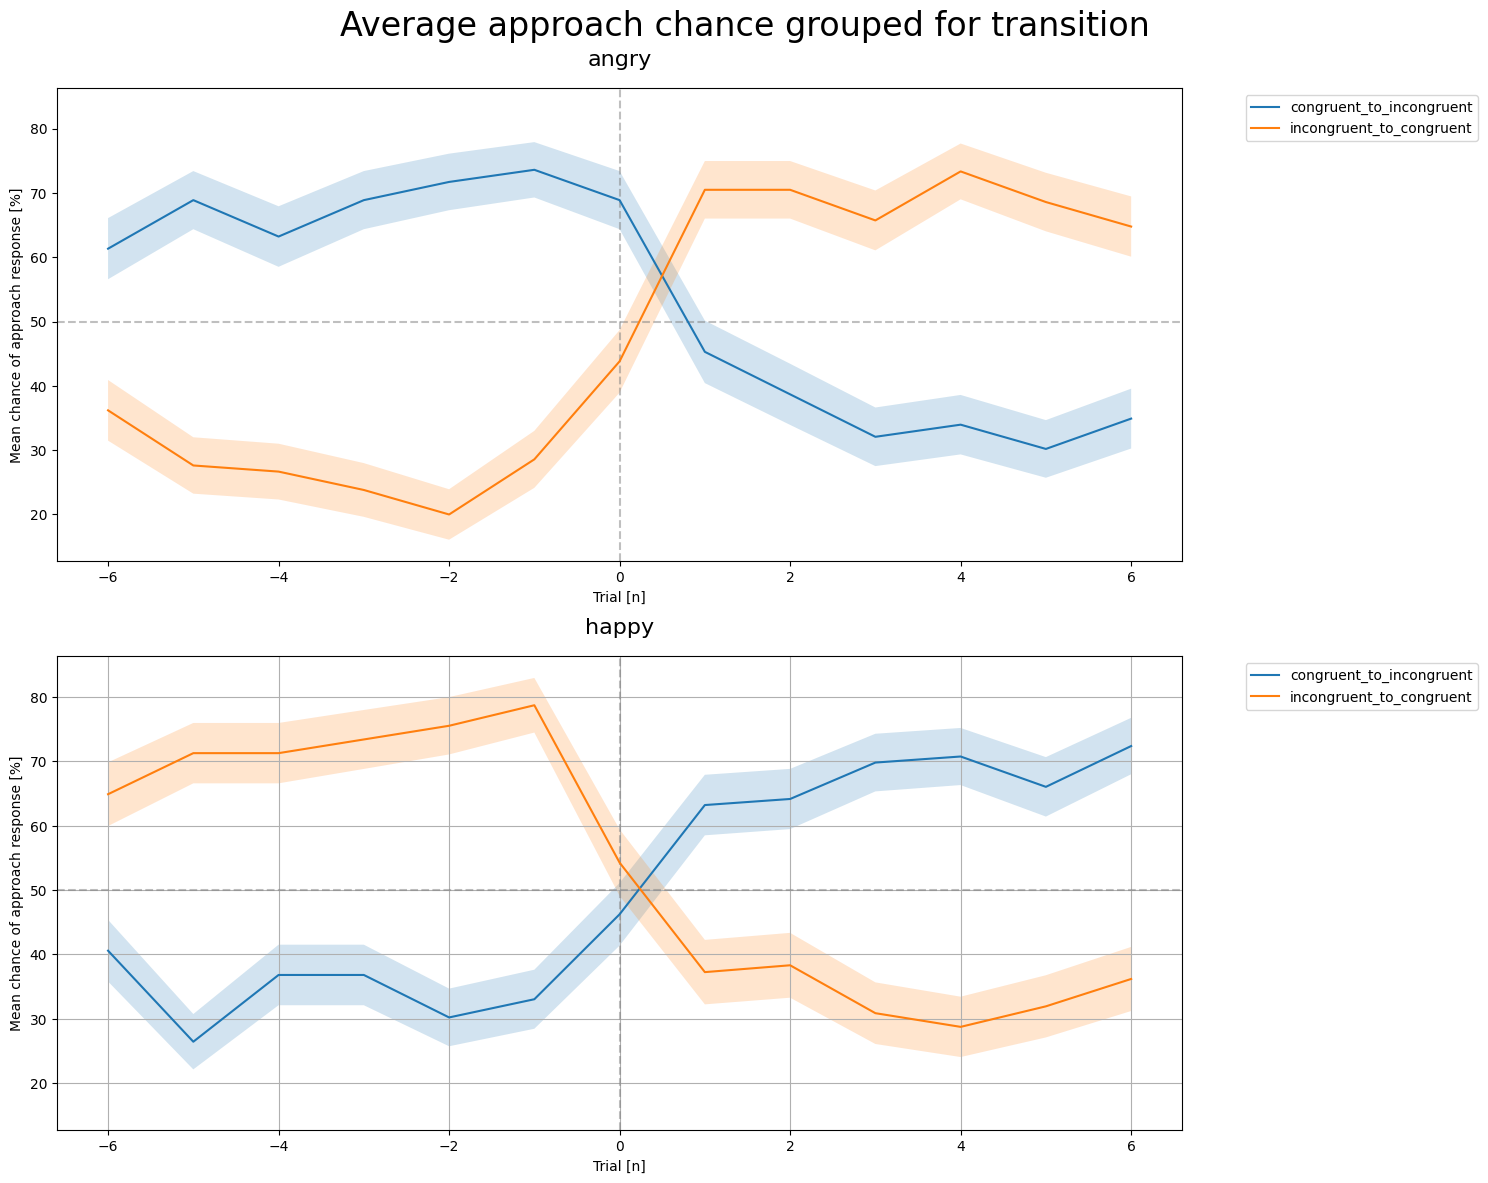

In [35]:
# Plotting with Matplotlib
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15, 12), sharey=True)

fig.suptitle('Average approach chance grouped for transition', fontsize=24, y=0.982)

# Plot each group
for valence_index, valence_value in enumerate(emotional_valences):
    axes[valence_index].axhline(50, color='grey', linestyle='dashed', alpha=0.5)
    axes[valence_index].axvline(0, color='grey', linestyle='dashed', alpha=0.5)
    for transition in transitions:
        subset = grouped_dataframe[(grouped_dataframe['emotional_valence'] == valence_value) & (grouped_dataframe['transition'] == transition)]
        current_emotion = subset['emotional_valence'].unique()
        current_transition = subset['transition'].unique()
        if not subset.empty:
            axes[valence_index].plot(subset['trials_around_switch'], subset['mean'], label=f'{transition}')
            axes[valence_index].fill_between(subset['trials_around_switch'], subset['mean'] - subset['sem'], subset['mean'] + subset['sem'], alpha=0.2)

    # Customize the plot
    axes[valence_index].set_xlabel('Trial [n]')
    axes[valence_index].set_ylabel('Mean chance of approach response [%]')
    axes[valence_index].set_title(valence_value, fontsize=16, y=1.03)
    axes[valence_index].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(True)
plt.tight_layout()

plt.savefig(os.path.join(output_dir, 'average_approach_chance_separated_by_valence_and_grouped_for_transition.pdf'))
# Show the plot
plt.show()

# Plot volatile and stable blocks separately

In [ ]:
import analysis_functions

pd.set_option('display.max_rows', None)
# Check if a block is volatile or stable
dataframe = combined_results_dataframe[combined_results_dataframe['probability_condition'] != 50]
dataframe = analysis_functions.check_volatility(dataframe)
dataframe = dataframe.sort_values(by=['subject_id', 'stimuli_type', 'trial'], ascending=[True, True, True])
print(dataframe[['subject_id', 'trial', 'stimuli_type', 'probability_condition', 'volatility']])

# Create new plots with different intervals that also contain the 50% trials
mapping = {0: 'subject_id', 1: 'stimuli_type', 2: 'volatility', 3: 0, 4: 1, 5: 2, 6: 3, 7: 4, 8: 5} #, 9: 6}#, 10: 7, 11: 8, 12: 9, 13: 10}
group_name = 'volatility'
unique_group_types = dataframe[group_name].unique()

dataframe = analysis_functions.find_switches_in_dataframe(dataframe, unique_subject_ids, unique_stimuli_types,
                                                                group_name, plot_range, mapping)

#print(dataframe)
pd.set_option('display.max_rows', 20)

     subject_id  trial  stimuli_type  probability_condition volatility
20       sub-02      9             1                     20   volatile
37       sub-02     10             1                     20   volatile
124      sub-02     14             1                     20   volatile
133      sub-02     15             1                     20   volatile
151      sub-02     16             1                     20   volatile
185      sub-02     18             1                     20   volatile
233      sub-02     20             1                     80   volatile
269      sub-02     22             1                     80   volatile
305      sub-02     24             1                     80   volatile
327      sub-02     26             1                     80   volatile
361      sub-02     28             1                     80   volatile
426      sub-02     31             1                     80   volatile
458      sub-02     33             1                     20   volatile
482   

c:\Users\marti\git\RL_task\analysis\analysis_functions.py:612: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  input_dataframe['switch'].iloc[0] = 'False'
c:\Users\marti\git\RL_task\analysis\analysis_functions.py:612: SettingWithCopyWarning: 


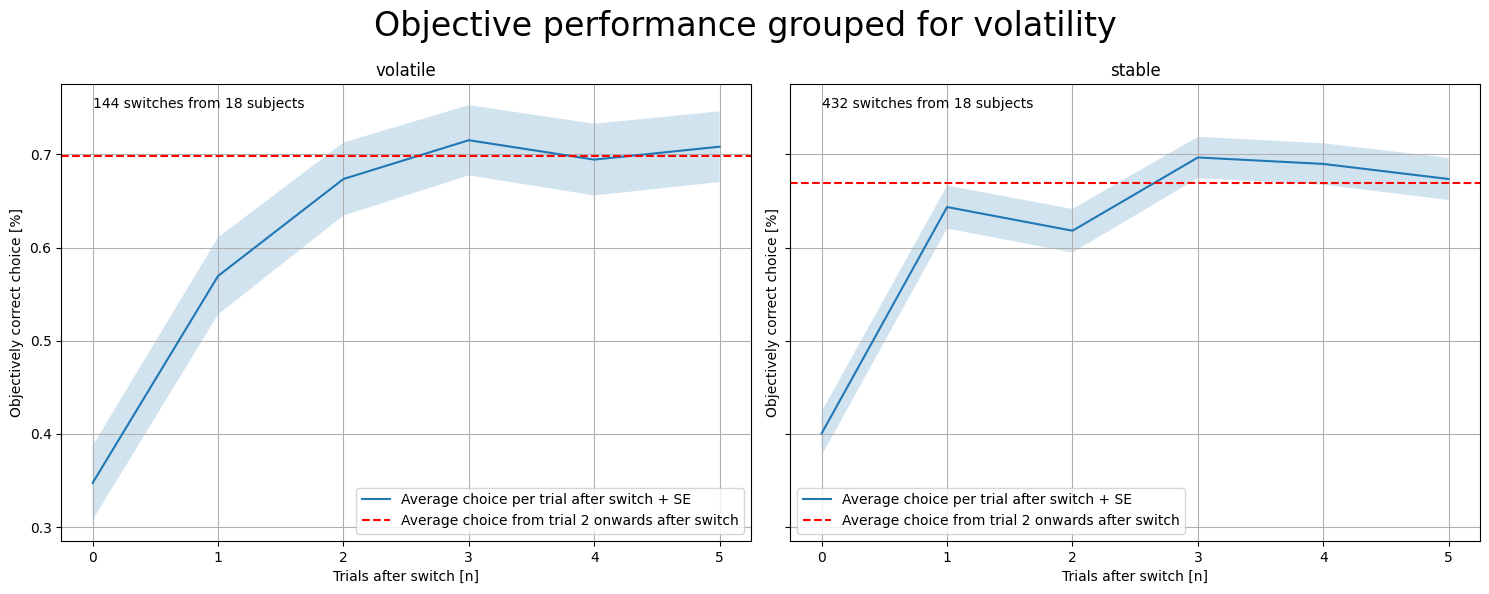

In [37]:
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = dataframe.set_index('volatility')

subject_counts = len(df['subject_id'].unique())

# Count the number of times both conditions were shown
group_counts = df.index.value_counts()

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id'])
df = df.drop(columns=['stimuli_type'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby('volatility').mean()
means_overall = means.iloc[:, 2:]
average_choice_after_switch_total = means_overall.mean(axis=1).tolist()
stds = df.groupby('volatility').sem()

# Plotting
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 6), sharex=False, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

fig.suptitle('Objective performance grouped for volatility', fontsize=24, y=0.982)

congruency_list = dataframe['volatility'].unique()

congruency_types = means.index
for i, congruency_type in enumerate(congruency_types):
    # Timepoints are the column names converted to integers for x-axis values
    timepoints = list(range(plot_range[0], plot_range[1]))
    mean_values = means.loc[congruency_type]
    std_values = stds.loc[congruency_type]

    axs[i].plot(timepoints, mean_values, label='Average choice per trial after switch + SE')
    axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
    axs[i].axhline((average_choice_after_switch_total[i]), color='r', linestyle='--', label='Average choice from trial 2 onwards after switch')
    #axs[i].plot(probability_dataframe_pivoted[i+1].dropna())
    axs[i].set_title(congruency_list[i])
    axs[i].set_xlabel('Trials after switch [n]')
    axs[i].set_ylabel('Objectively correct choice [%]')
    axs[i].text(0, 0.75, f'{group_counts[congruency_type]} switches from {subject_counts} subjects', fontsize=10)
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objective_performance_grouped_for_volatility.pdf'))
plt.show()

# Now do the same thing but split them for congruency

In [38]:
# Check if a block is volatile or stable
dataframe = combined_results_dataframe[combined_results_dataframe['probability_condition'] != 50]
dataframe = analysis_functions.check_volatility(dataframe)
dataframe = dataframe.sort_values(by=['subject_id', 'stimuli_type', 'trial'], ascending=[True, True, True])
#print(dataframe)

# Create new plots with different intervals that also contain the 50% trials
mapping = {0: 'subject_id', 1: 'stimuli_type', 2: 'congruency', 3: 'volatility', 4: 0, 5: 1, 6: 2, 7: 3, 8: 4, 9: 5, 10: 6}#, 11:7, 12:8, 13: 9, 14: 10}
group_name = 'volatility'
unique_group_types = dataframe[group_name].unique()


dataframe = analysis_functions.find_switches_in_dataframe(dataframe, unique_subject_ids, unique_stimuli_types,
                                                                'volatility', plot_range, mapping, 'congruency')

#print(dataframe.to_string())

     subject_id  trial  stimuli_type  probability_condition switch volatility  \
20       sub-02      9             1                     20  False   volatile   
37       sub-02     10             1                     20  False   volatile   
124      sub-02     14             1                     20  False   volatile   
133      sub-02     15             1                     20  False   volatile   
151      sub-02     16             1                     20  False   volatile   
...         ...    ...           ...                    ...    ...        ...   
7815     sub-21    442             3                     80  False     stable   
7862     sub-21    444             3                     80  False     stable   
7888     sub-21    446             3                     80  False     stable   
7930     sub-21    448             3                     80  False     stable   
7938     sub-21    449             3                     80  False     stable   

       congruency  
20    i

c:\Users\marti\git\RL_task\analysis\analysis_functions.py:612: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  input_dataframe['switch'].iloc[0] = 'False'
c:\Users\marti\git\RL_task\analysis\analysis_functions.py:612: SettingWithCopyWarning: 


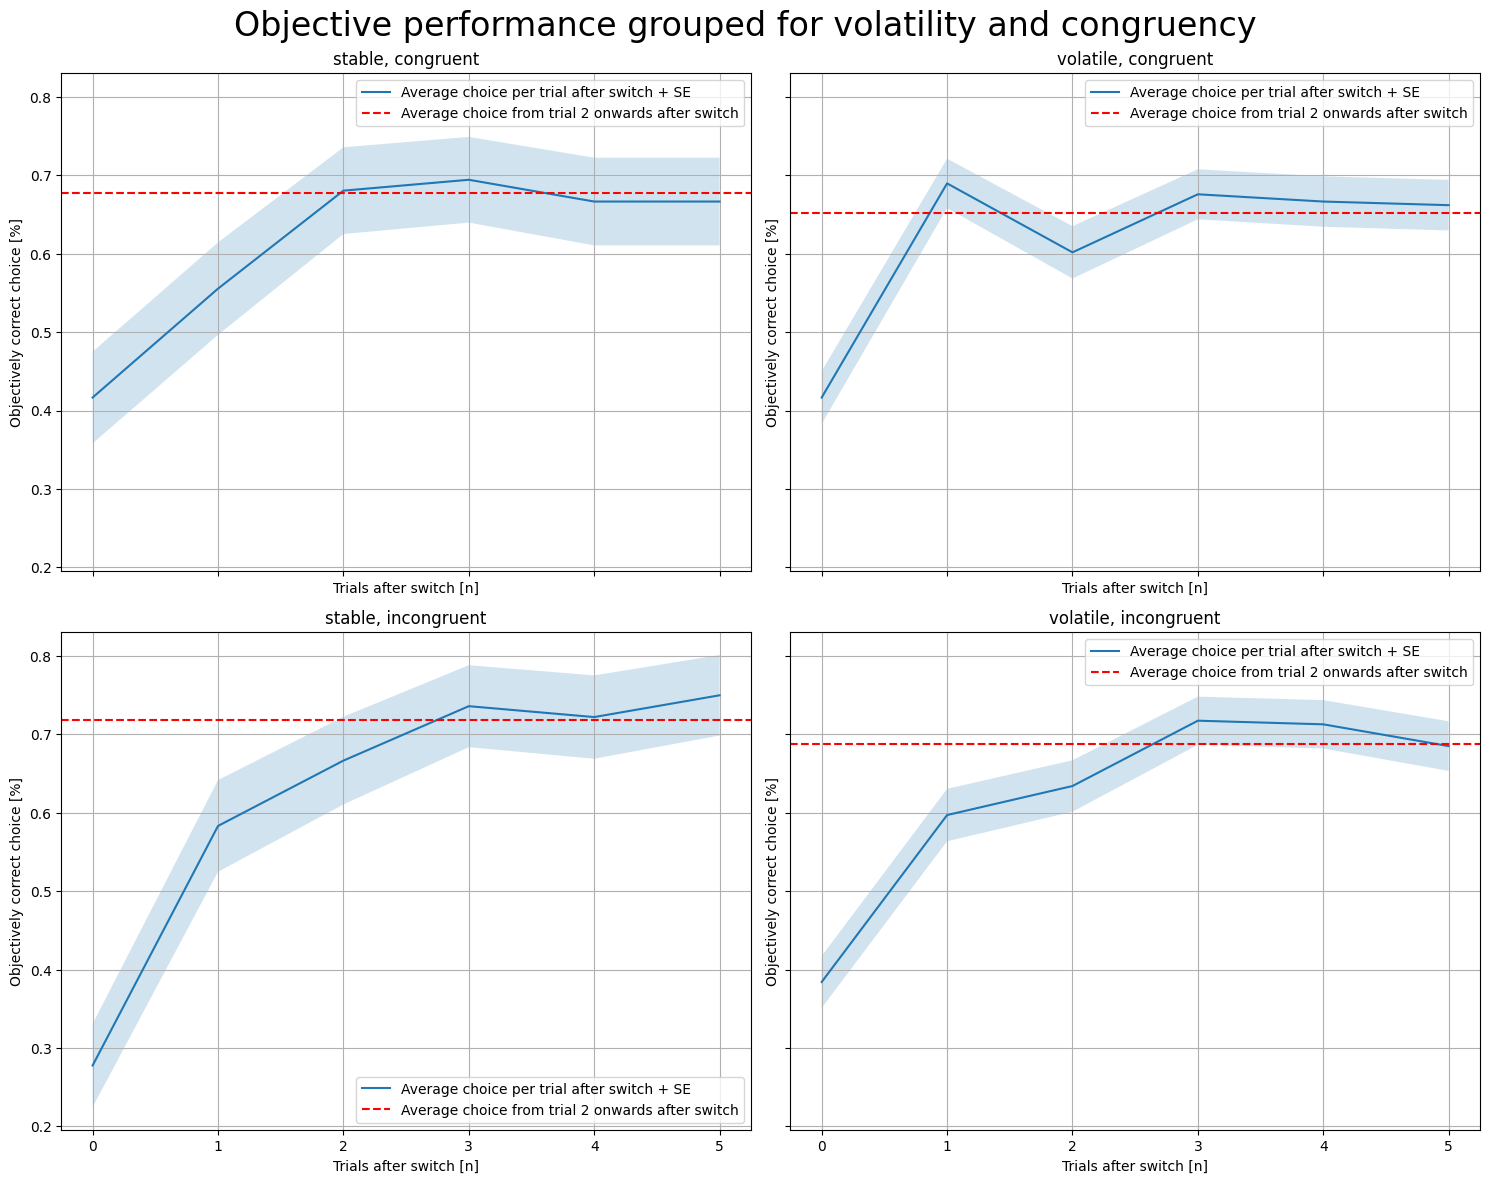

In [39]:
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = dataframe

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id', 'stimuli_type'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby(['congruency', 'volatility']).mean()
means_overall = means.iloc[:, 2:]
average_choice_after_switch_total = means_overall.mean(axis=1).tolist()

stds = df.groupby(['congruency', 'volatility']).sem()

# Plotting
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(15, 12), sharex=True, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

fig.suptitle('Objective performance grouped for volatility and congruency', fontsize=24, y=0.982)

congruency_list = df['congruency'].unique()
volatility_list = df['volatility'].unique()

congruency_types = means.index
for i, congruency_type in enumerate(congruency_types):
    # Timepoints are the column names converted to integers for x-axis values
    timepoints = list(range(plot_range[0], plot_range[1]))
    mean_values = means.loc[congruency_type]
    std_values = stds.loc[congruency_type]

    axs[i].plot(timepoints, mean_values, label='Average choice per trial after switch + SE')
    axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
    axs[i].axhline((average_choice_after_switch_total[i]), color='r', linestyle='--', label='Average choice from trial 2 onwards after switch')
    #axs[i].plot(probability_dataframe_pivoted[i+1].dropna())
    axs[i].set_title(f'{congruency_type[1]}, {congruency_type[0]}')
    axs[i].set_xlabel('Trials after switch [n]')
    axs[i].set_ylabel('Objectively correct choice [%]')
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objective_performance_grouped_for_volatility_and_congruency.pdf'))
plt.show()

# Plot the full stable block

In [40]:
# Check if a block is volatile or stable
dataframe = combined_results_dataframe[combined_results_dataframe['probability_condition'] != 50]
dataframe = analysis_functions.check_volatility(dataframe)
dataframe = dataframe.sort_values(by=['subject_id', 'stimuli_type', 'trial'], ascending=[True, True, True])

# Create a dictionary based on the plot range
initial_columns = {0: 'subject_id', 1: 'stimuli_type', 2: 'volatility'}
adjusted_plot_range = [0, 28]
# Append the plot range to the existing dictionary
mapping = initial_columns.copy()
mapping.update({k+3: v for k, v in enumerate(plot_range)})

# Define the to be plotted factor
group_name = 'volatility'
unique_group_types = dataframe[group_name].unique()

dataframe = analysis_functions.find_switches_in_dataframe(dataframe, unique_subject_ids, unique_stimuli_types,
                                                                'volatility', adjusted_plot_range, mapping)

print(dataframe)

     subject_id  trial  stimuli_type  probability_condition switch volatility
20       sub-02      9             1                     20  False   volatile
37       sub-02     10             1                     20  False   volatile
124      sub-02     14             1                     20  False   volatile
133      sub-02     15             1                     20  False   volatile
151      sub-02     16             1                     20  False   volatile
...         ...    ...           ...                    ...    ...        ...
7815     sub-21    442             3                     80  False     stable
7862     sub-21    444             3                     80  False     stable
7888     sub-21    446             3                     80  False     stable
7930     sub-21    448             3                     80  False     stable
7938     sub-21    449             3                     80  False     stable

[7992 rows x 6 columns]
0   subject_id stimuli_type volatility 

c:\Users\marti\git\RL_task\analysis\analysis_functions.py:612: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  input_dataframe['switch'].iloc[0] = 'False'
c:\Users\marti\git\RL_task\analysis\analysis_functions.py:612: SettingWithCopyWarning: 


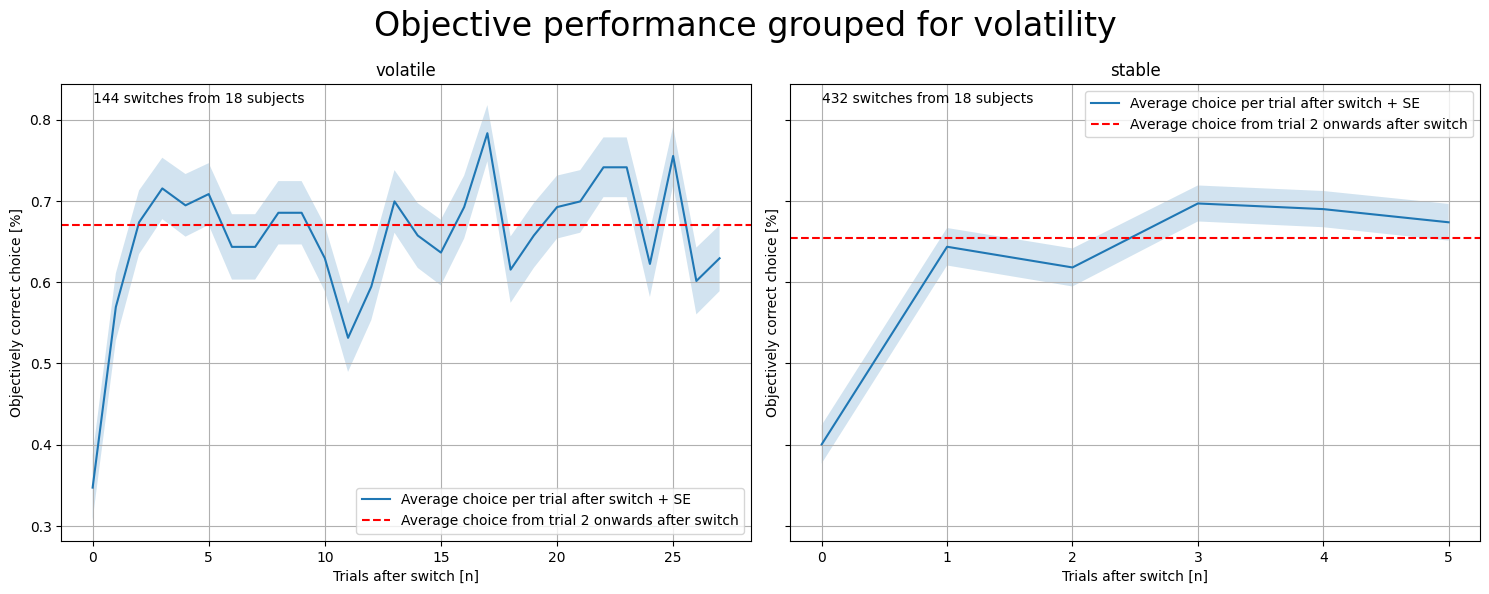

In [41]:
# Remove volatile rows
df = dataframe.set_index('volatility')

subject_counts = len(df['subject_id'].unique())

# Count the number of times both conditions were shown
group_counts = df.index.value_counts()

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id'])
df = df.drop(columns=['stimuli_type'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby('volatility').mean()
means_overall = means.iloc[:, 2:]
average_choice_after_switch_total = (means_overall.mean(axis=1).tolist())
stds = df.groupby('volatility').sem()

# Plotting
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 6), sharex=False, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

fig.suptitle('Objective performance grouped for volatility', fontsize=24, y=0.982)

congruency_list = dataframe['volatility'].unique()

congruency_types = means.index
for i, congruency_type in enumerate(congruency_types):
    # Timepoints are the column names converted to integers for x-axis values

    mean_values = means.loc[congruency_type]
    std_values = stds.loc[congruency_type]
    
    if congruency_type == 'stable':
        timepoints = list(range(adjusted_plot_range[0], adjusted_plot_range[1]))
    else:
        volatile_duration = 6
        timepoints = list(range(0, volatile_duration))
        mean_values = mean_values.iloc[:volatile_duration]
        std_values = std_values.iloc[:volatile_duration]

    axs[i].plot(timepoints, mean_values, label='Average choice per trial after switch + SE')
    axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
    axs[i].axhline(average_choice_after_switch_total[i], color='r', linestyle='--', label='Average choice from trial 2 onwards after switch')
    #axs[i].plot(probability_dataframe_pivoted[i+1].dropna())
    axs[i].set_title(congruency_list[i])
    axs[i].set_xlabel('Trials after switch [n]')
    axs[i].set_ylabel('Objectively correct choice [%]')
    axs[i].text(0, 0.82, f'{group_counts[congruency_type]} switches from {subject_counts} subjects', fontsize=10)
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objective_performance_for_full_stable_block.pdf'))
plt.show()

In [42]:
# Check if a block is volatile or stable
dataframe = combined_results_dataframe[combined_results_dataframe['probability_condition'] != 50]
dataframe = analysis_functions.check_volatility(dataframe)
dataframe = dataframe.sort_values(by=['subject_id', 'stimuli_type', 'trial'], ascending=[True, True, True])

# Then bin the area around a switch
adjusted_plot_range = [plot_range[0] - plot_range[1], plot_range[1]]
dataframe = analysis_functions.bin_responses_for_congruency(dataframe, adjusted_plot_range, 'volatility')

c:\Users\marti\git\RL_task\analysis\analysis_functions.py:187: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dataframe[new_column] = dataframe[old_column].replace(mapping)


[5, 11, 21, 31, 39, 49, 81, 113, 122, 128, 135, 143, 151, 156, 184, 212, 218, 224, 230, 240, 250, 258, 268, 300, 331, 341, 347, 355, 363, 371, 377, 404, 432, 443, 451, 457, 465, 470, 480, 508, 540, 546, 554, 564, 574, 582, 592, 619, 651, 657, 663, 671, 675, 683, 689, 699, 726, 758, 764, 772, 782, 792, 799, 809, 837, 869, 880, 888, 894, 904, 914, 922, 950, 981, 988, 994, 1002, 1012, 1018, 1028, 1055, 1087, 1093, 1099, 1107, 1113, 1123, 1132, 1139, 1167, 1199, 1207, 1213, 1221, 1231, 1237, 1247, 1273, 1305, 1311, 1342, 1372, 1382, 1386, 1396, 1404, 1410, 1419, 1447, 1474, 1482, 1491, 1497, 1505, 1513, 1519, 1525, 1554, 1594, 1600, 1609, 1616, 1622, 1631, 1659, 1686, 1694, 1704, 1717, 1725, 1731, 1764, 1791, 1798, 1806, 1814, 1820, 1830, 1838, 1870, 1900, 1906, 1916, 1926, 1932, 1938, 1948, 1953, 1981, 2009, 2017, 2025, 2033, 2039, 2056, 2088, 2120, 2126, 2136, 2146, 2152, 2158, 2168, 2194, 2221, 2229, 2237, 2243, 2253, 2257, 2265, 2295, 2325, 2333, 2339, 2347, 2356, 2362, 2372, 2378, 240

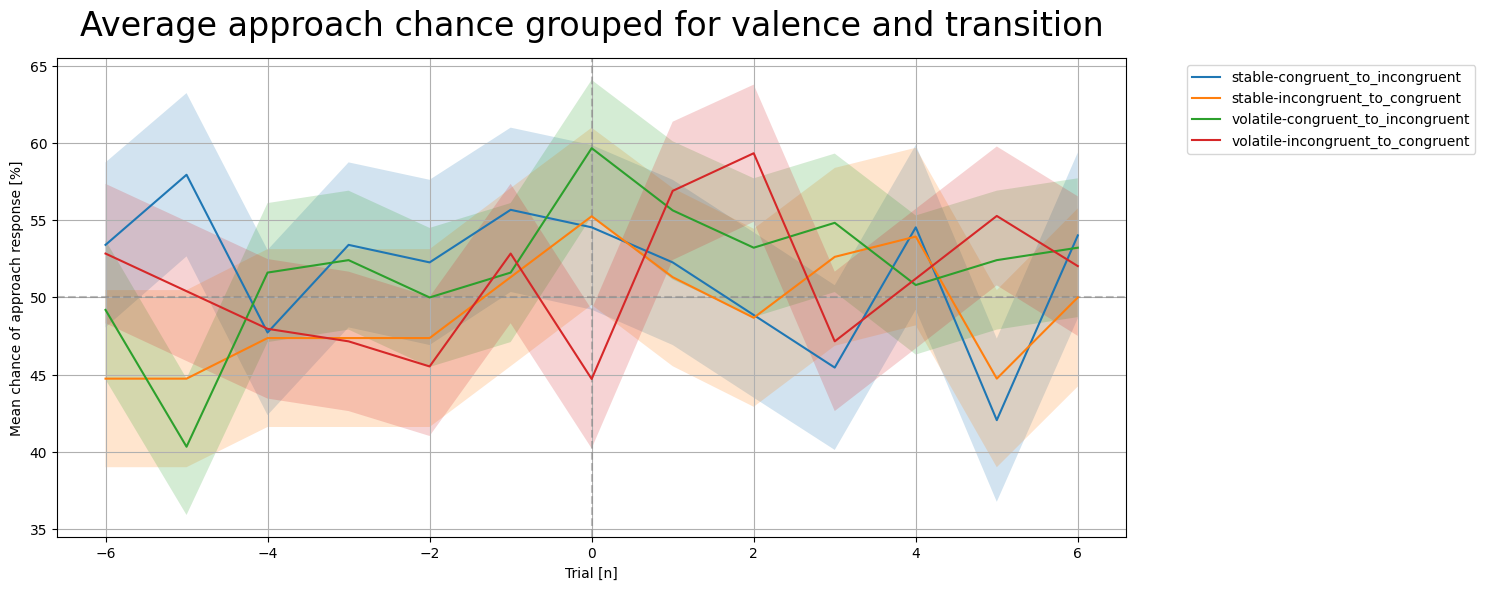

In [43]:
# Group the data
grouped_dataframe = dataframe.groupby(['trials_around_switch', 'volatility', 'transition'])['response_int'].agg(['mean', 'sem']).reset_index()

# Plotting with Matplotlib
plt.figure(figsize=(15, 6))

# Define the unique groups for 'emotional_valence' and 'transition'
emotional_valences = grouped_dataframe['volatility'].unique()
transitions = grouped_dataframe['transition'].unique()
transitions = transitions[transitions != 'no_transition']

# Plot each group
plt.axhline(50, color='grey', linestyle='dashed', alpha=0.5)
plt.axvline(0, color='grey', linestyle='dashed', alpha=0.5)
for valence in emotional_valences:
    for transition in transitions:
        subset = grouped_dataframe[(grouped_dataframe['volatility'] == valence) & (grouped_dataframe['transition'] == transition)]
        current_emotion = subset['volatility'].unique()
        current_transition = subset['transition'].unique()
        if not subset.empty:
            plt.plot(subset['trials_around_switch'], subset['mean'], label=f'{valence}-{transition}')
            plt.fill_between(subset['trials_around_switch'], subset['mean'] - subset['sem'], subset['mean'] + subset['sem'], alpha=0.2)

# Customize the plot
plt.xlabel('Trial [n]')
plt.ylabel('Mean chance of approach response [%]')
plt.title('Average approach chance grouped for valence and transition', fontsize=24, y=1.03)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()

plt.savefig(os.path.join(output_dir, 'average_approach_chance_grouped_for_volatility_and_transition.pdf'))
# Show the plot
plt.show()

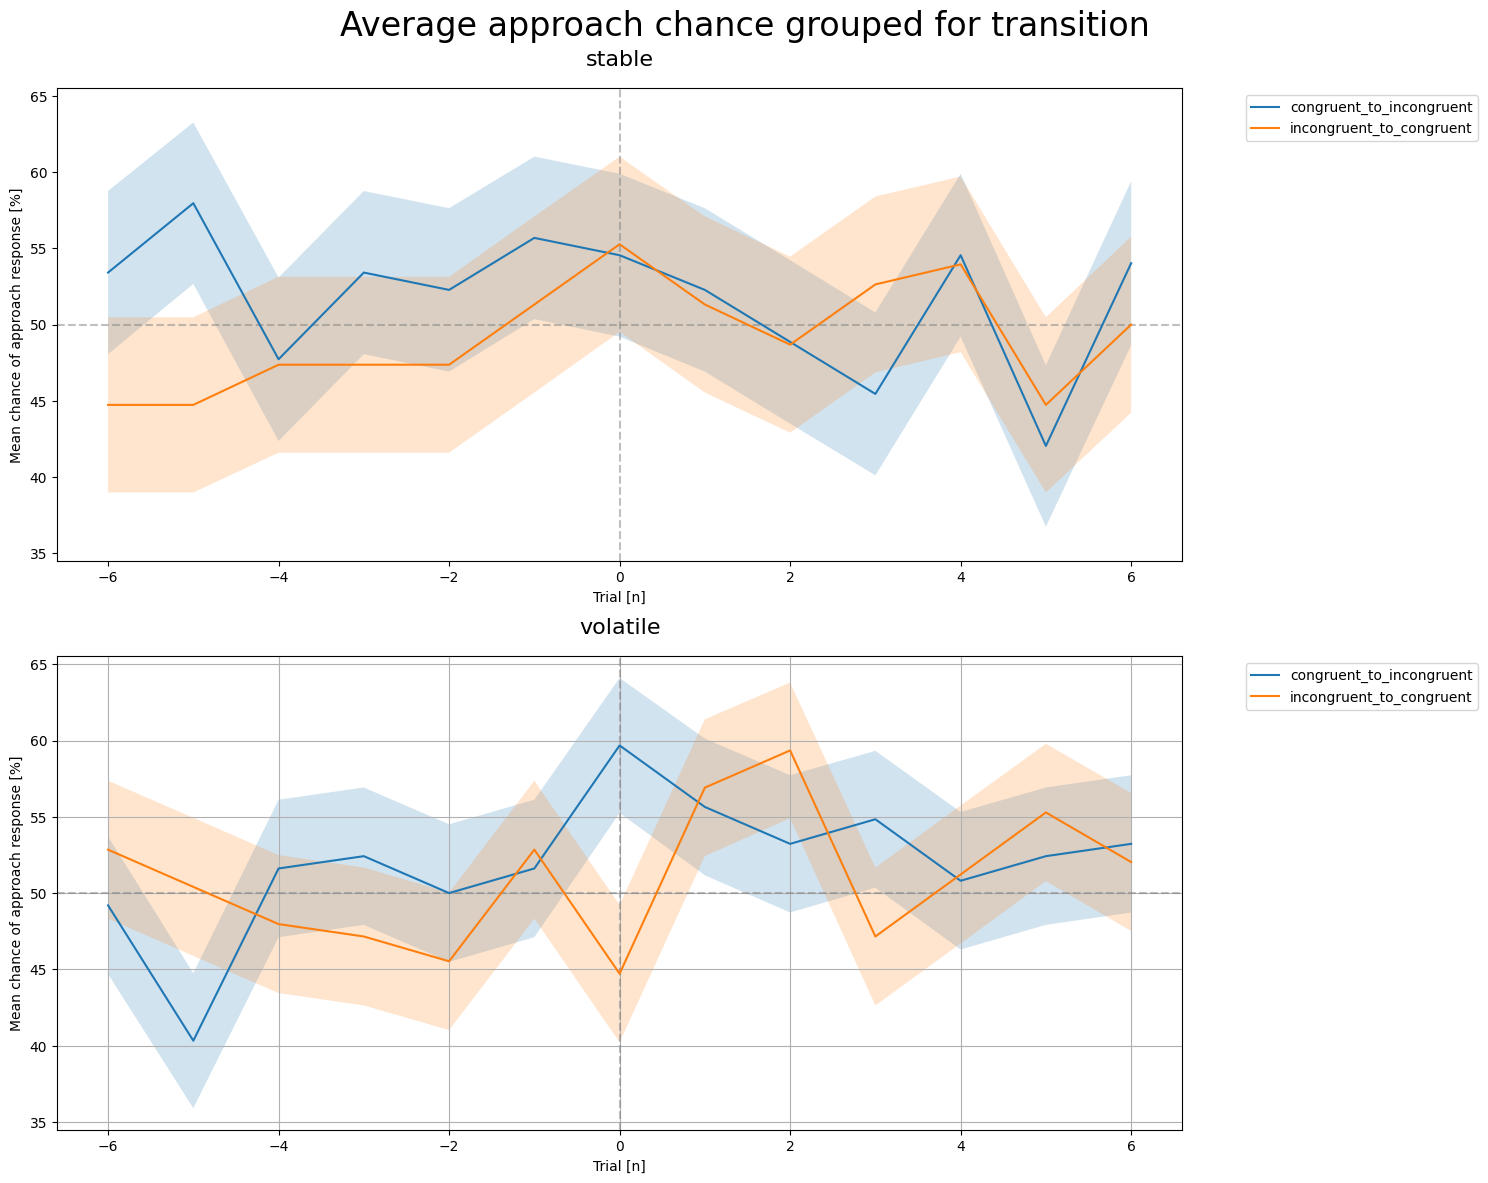

In [44]:
# Plotting with Matplotlib
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15, 12), sharey=True)

fig.suptitle('Average approach chance grouped for transition', fontsize=24, y=0.982)

# Plot each group
for valence_index, valence_value in enumerate(emotional_valences):
    axes[valence_index].axhline(50, color='grey', linestyle='dashed', alpha=0.5)
    axes[valence_index].axvline(0, color='grey', linestyle='dashed', alpha=0.5)
    for transition in transitions:
        subset = grouped_dataframe[(grouped_dataframe['volatility'] == valence_value) & (grouped_dataframe['transition'] == transition)]
        current_emotion = subset['volatility'].unique()
        current_transition = subset['transition'].unique()
        if not subset.empty:
            axes[valence_index].plot(subset['trials_around_switch'], subset['mean'], label=f'{transition}')
            axes[valence_index].fill_between(subset['trials_around_switch'], subset['mean'] - subset['sem'], subset['mean'] + subset['sem'], alpha=0.2)

    # Customize the plot
    axes[valence_index].set_xlabel('Trial [n]')
    axes[valence_index].set_ylabel('Mean chance of approach response [%]')
    axes[valence_index].set_title(valence_value, fontsize=16, y=1.03)
    axes[valence_index].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(True)
plt.tight_layout()

plt.savefig(os.path.join(output_dir, 'average_approach_chance_separated_by_volatility_and_grouped_for_transition.pdf'))
# Show the plot
plt.show()